----
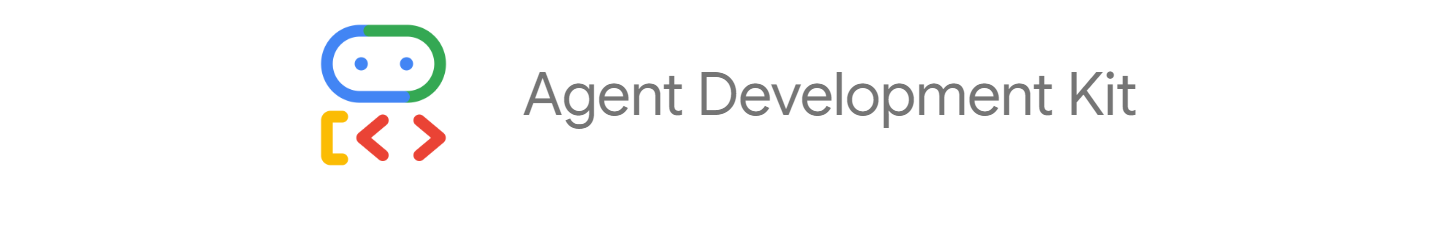

---

# ADK - Deploy to Vertex AI Agent Engine
[Agent Engine](https://cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/overview) is a fully managed Google Cloud service enabling developers to deploy, manage, and scale AI agents in production. Agent Engine handles the infrastructure to scale agents in production so you can focus on creating intelligent and impactful applications. This guide provides an accelerated deployment instruction set for when you want to deploy an ADK project quickly, and a standard, step-by-step set of instructions for when you want to carefully manage deploying an agent to Agent Engine. <br> 

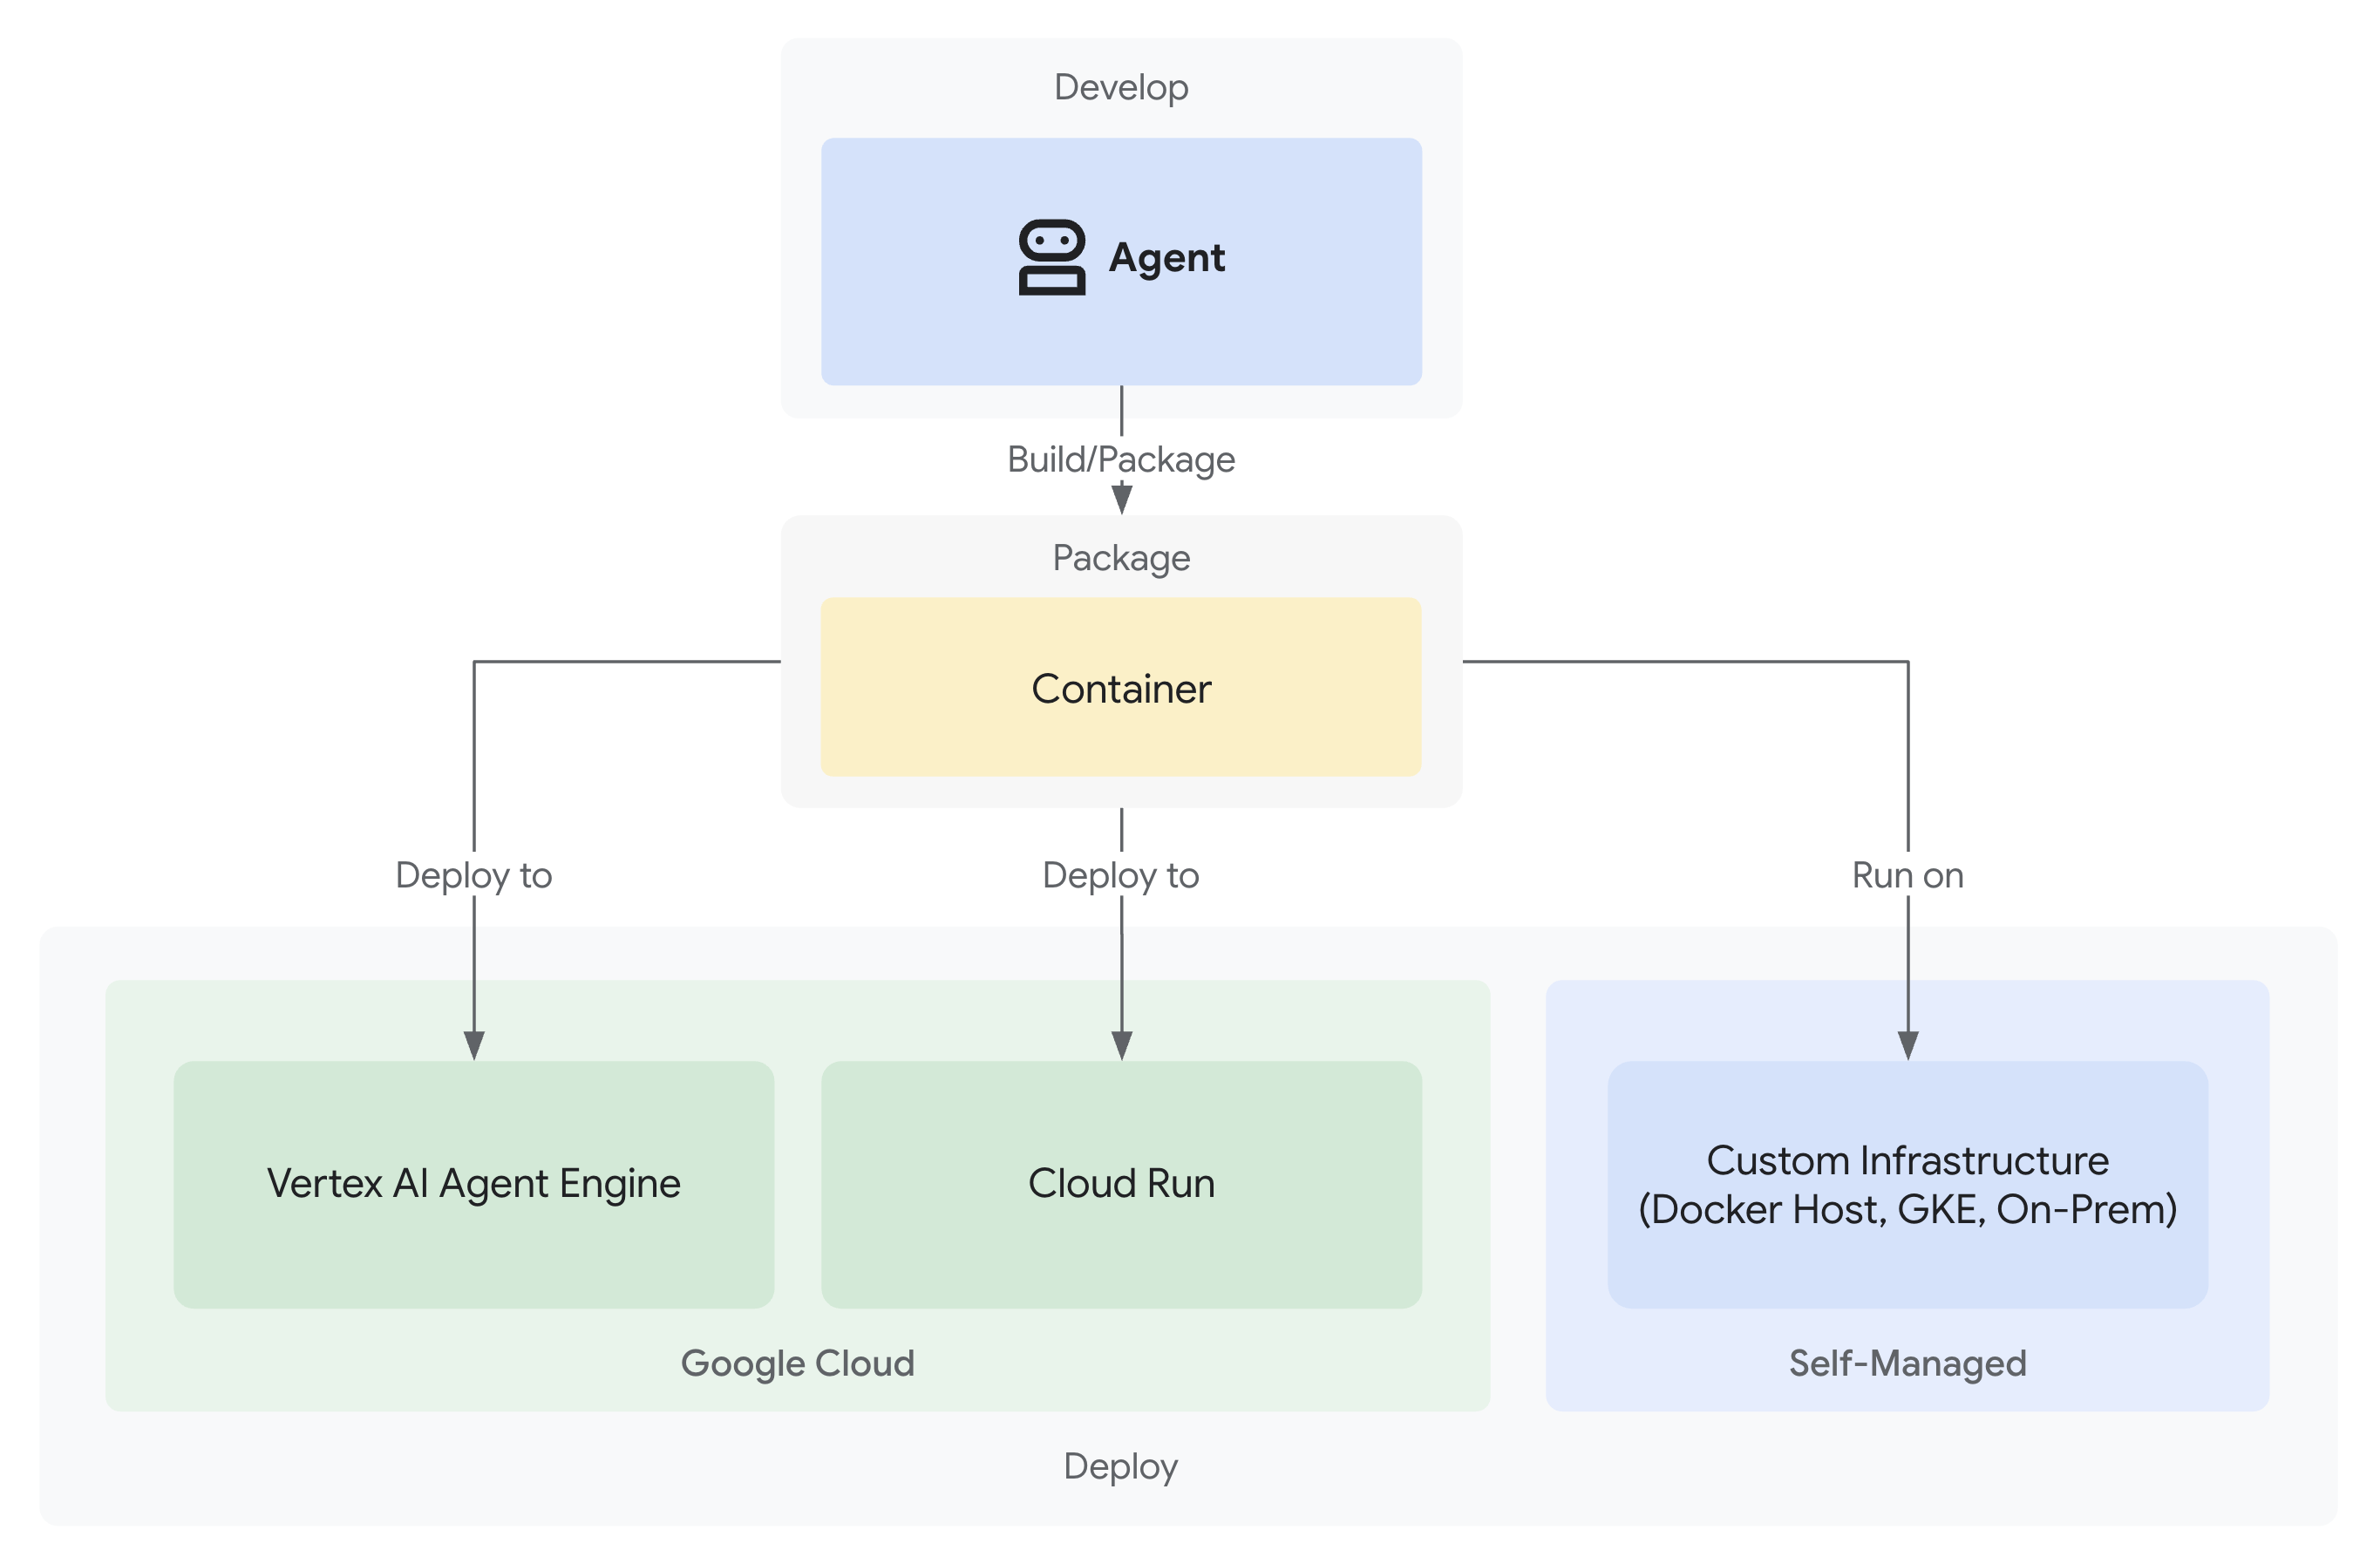

## Vertex AI Agent Engine overview [Learn more](https://cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/overview)
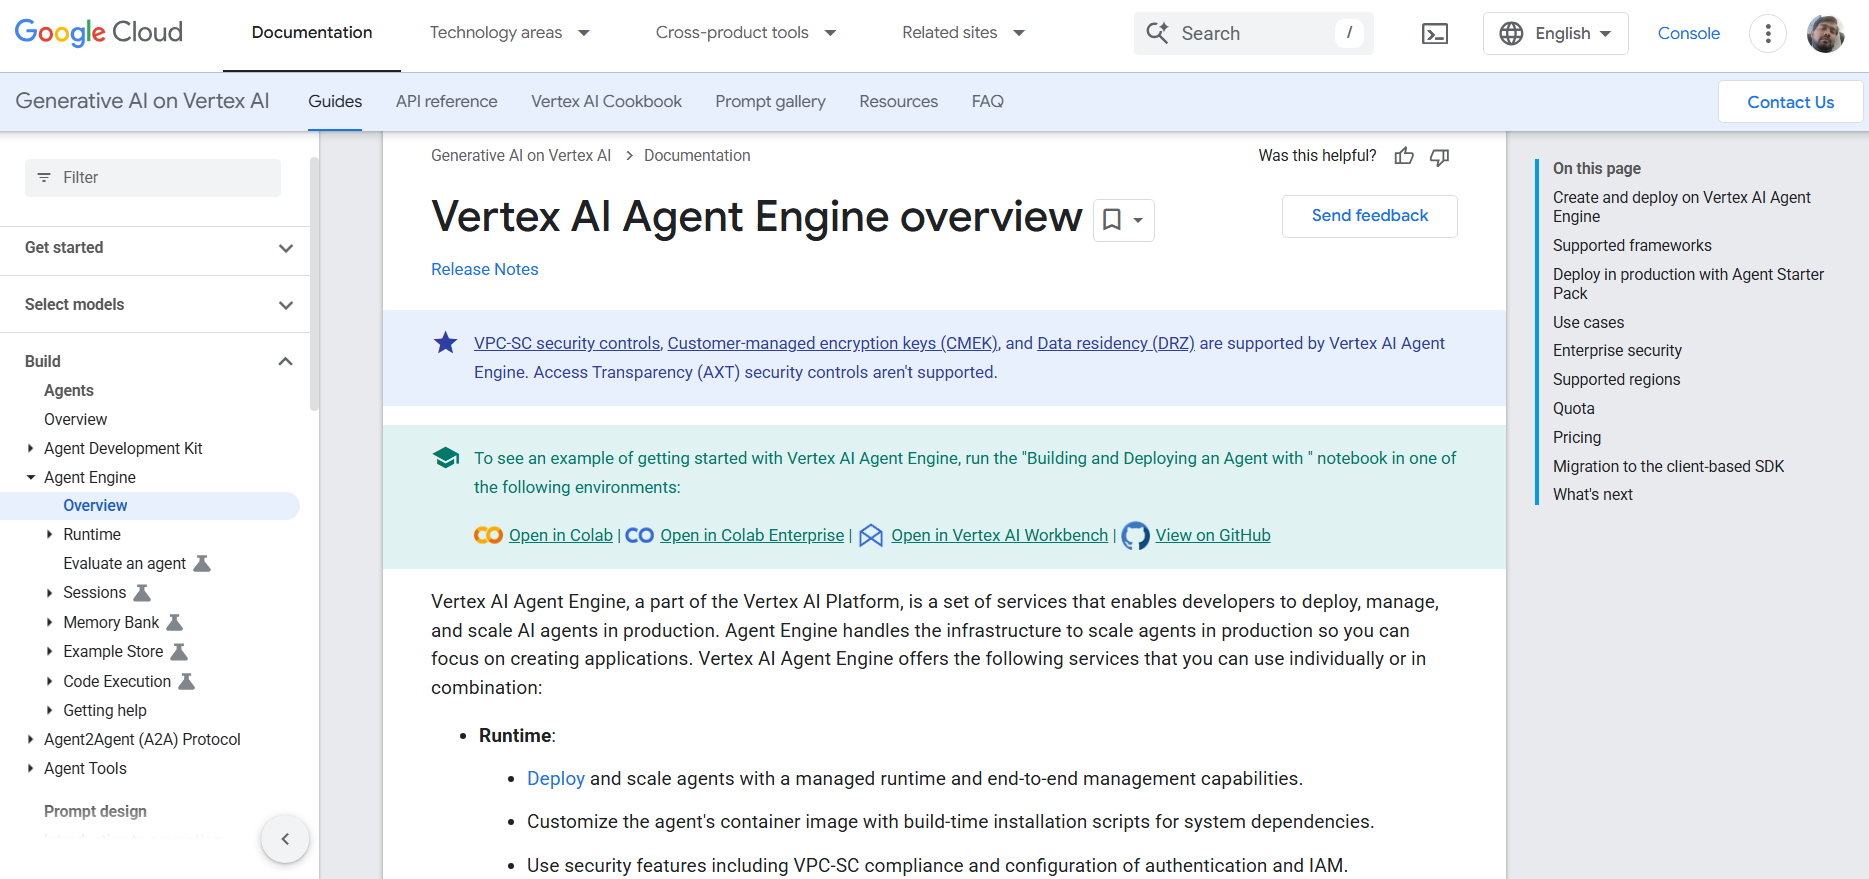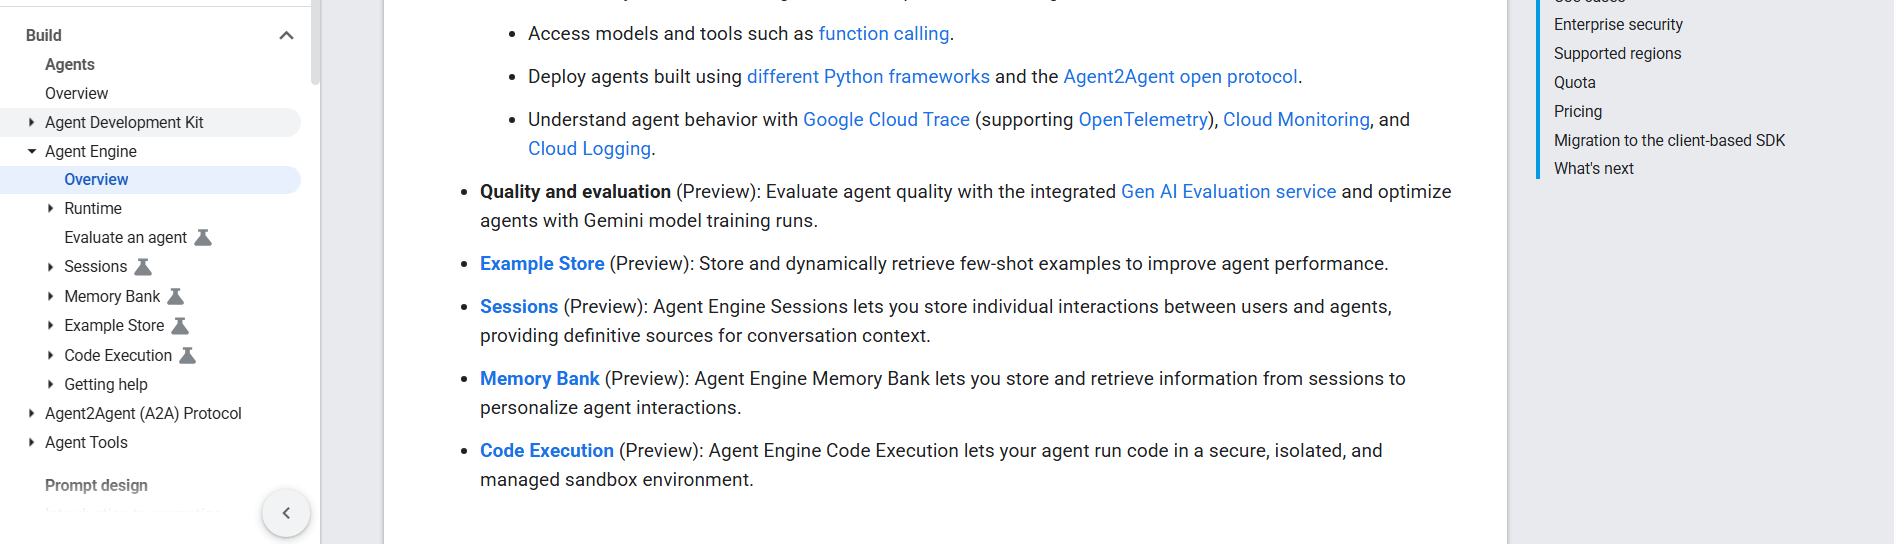 <br><br>

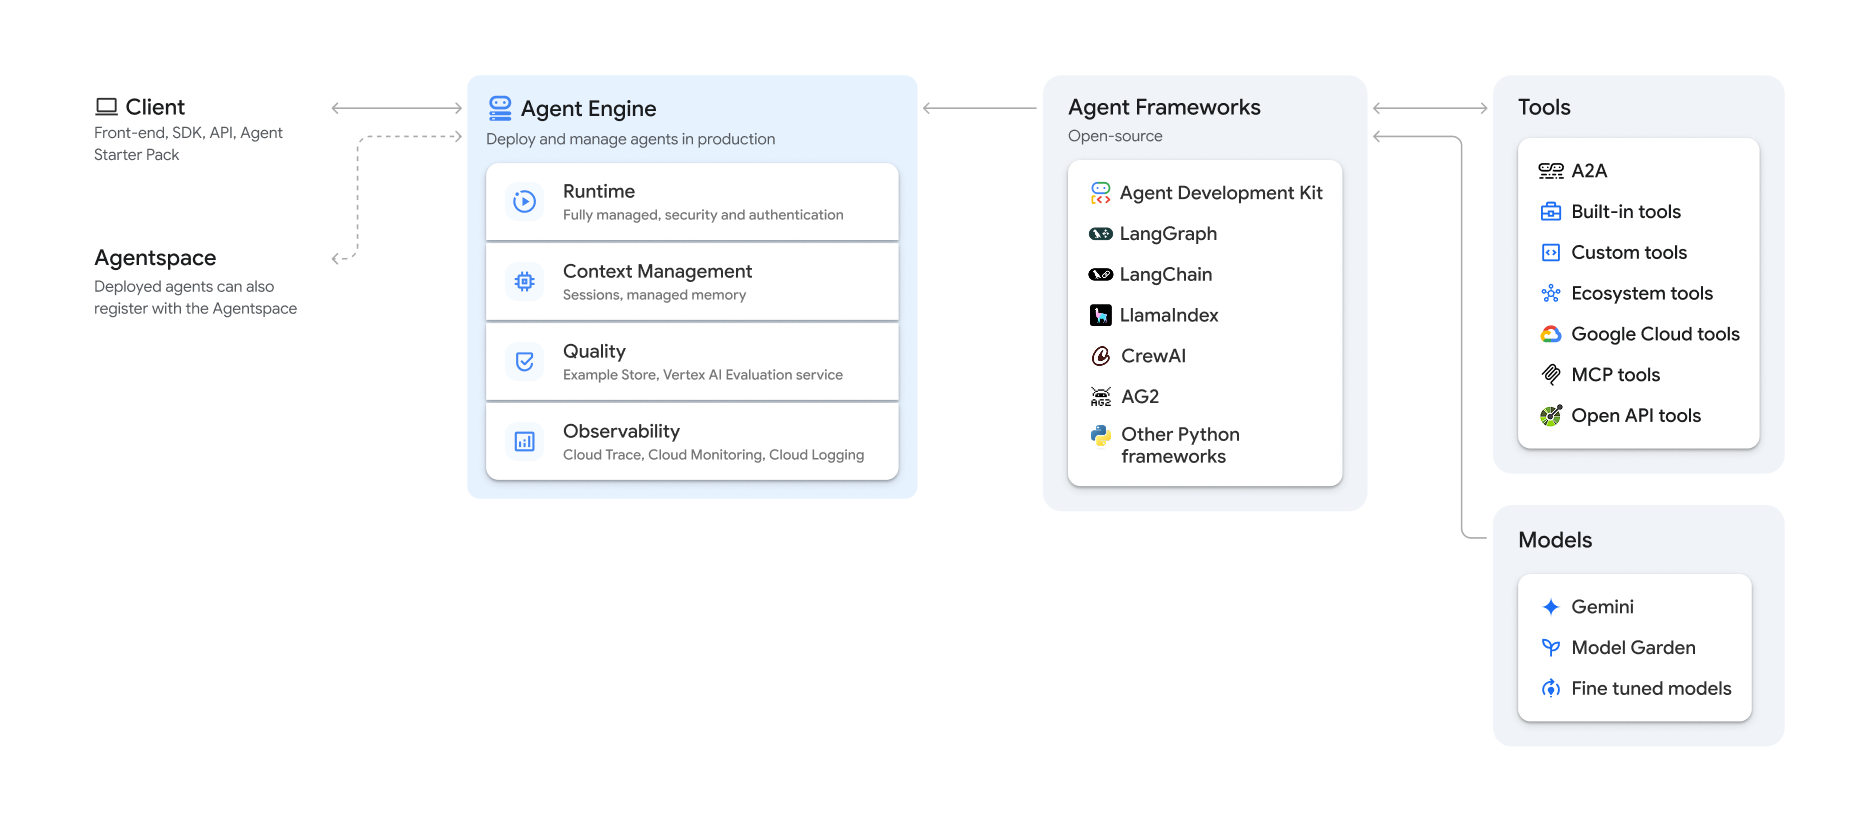 <br><br> 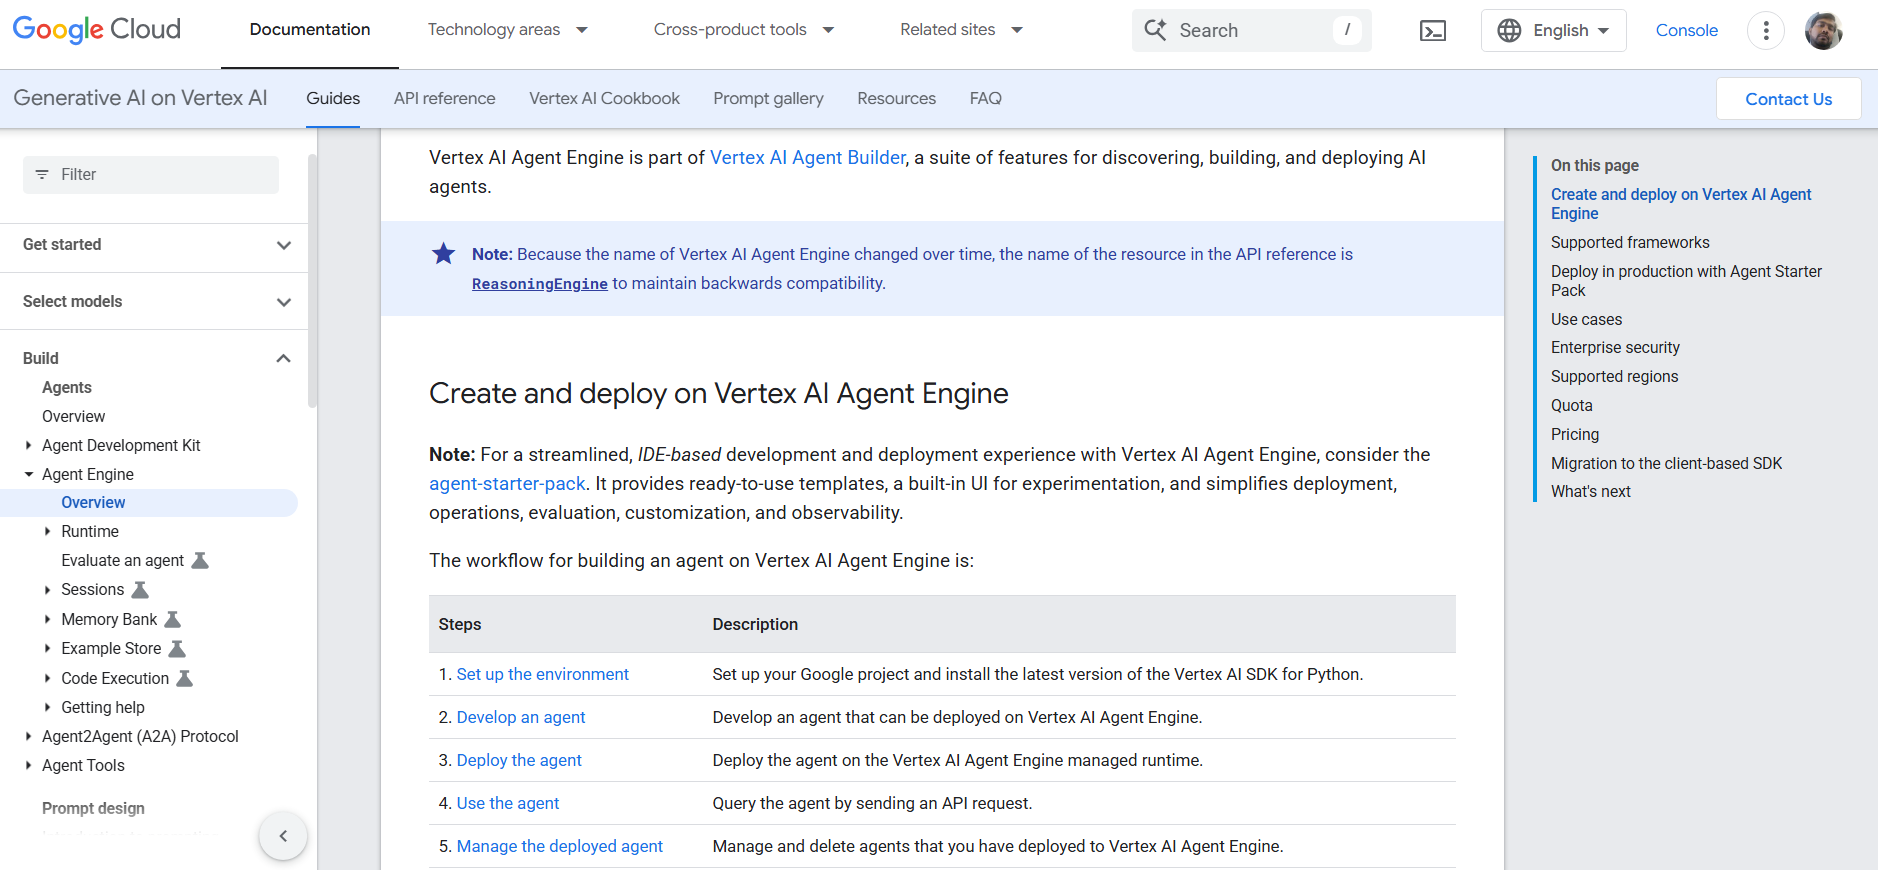 <br><br> 

### `The steps are illustrated by the following diagram:`
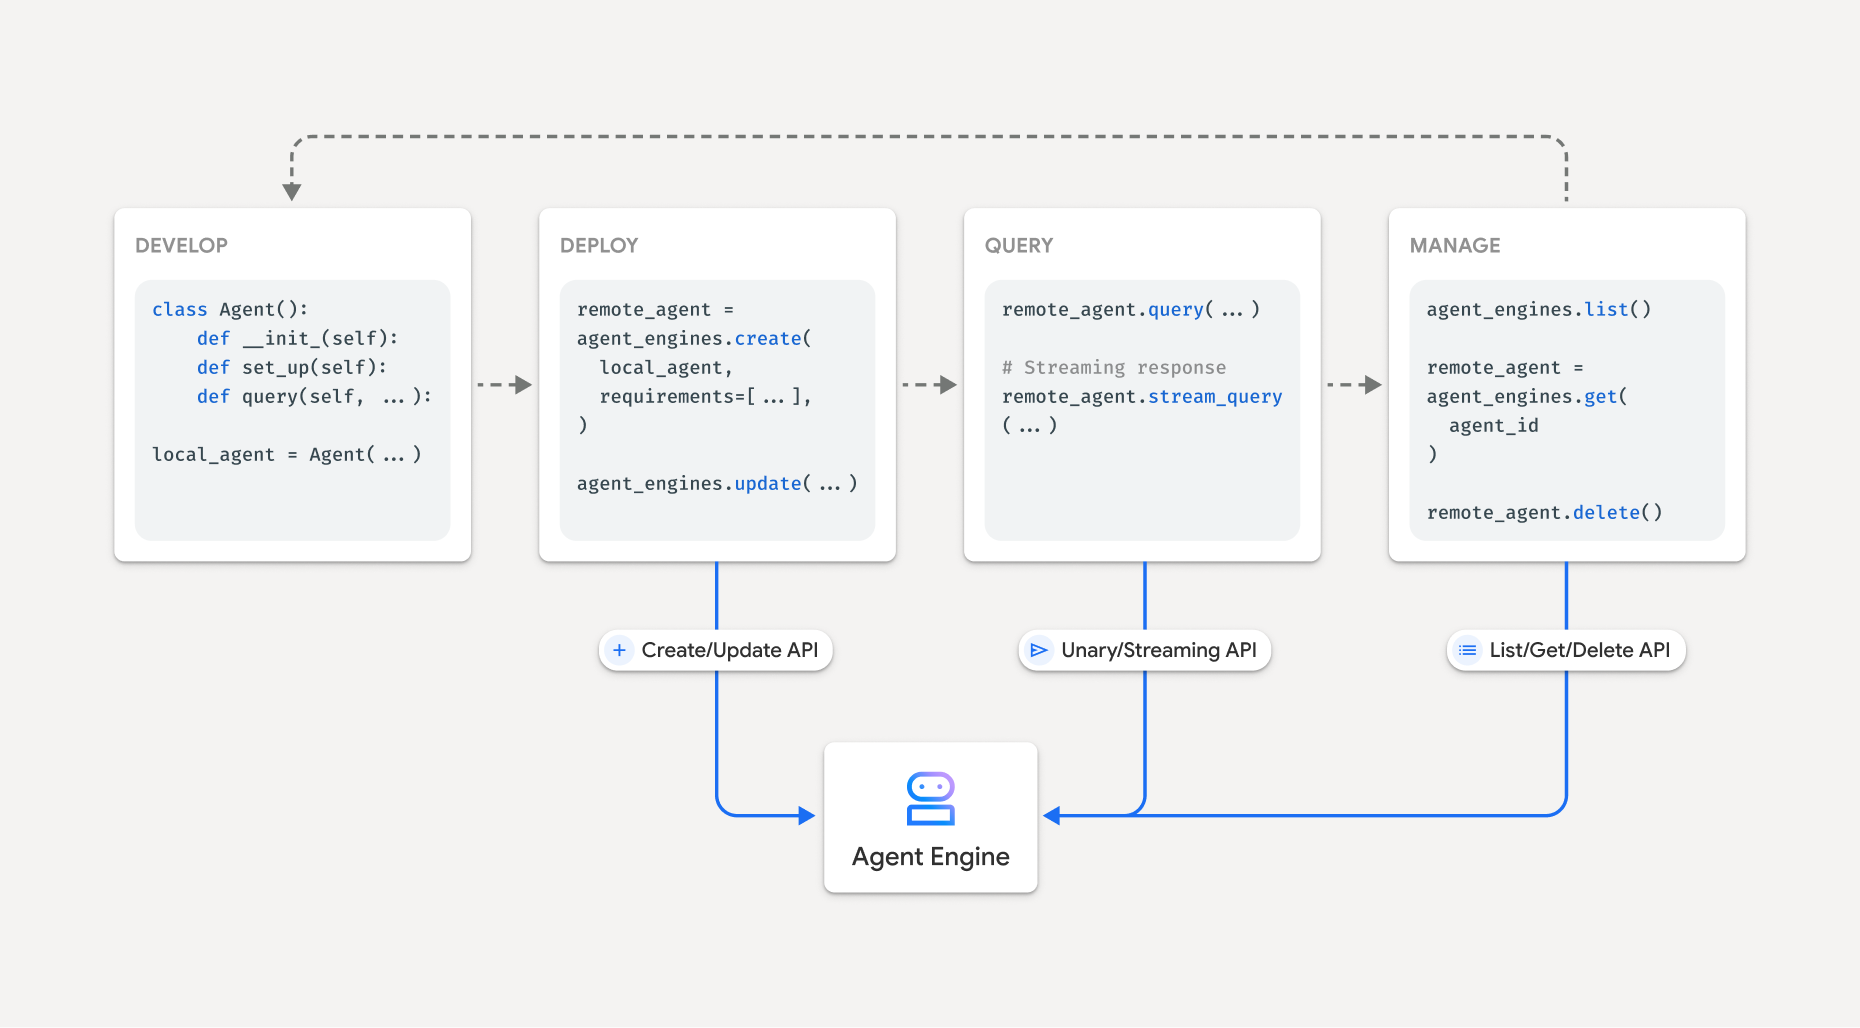 

<br><br> 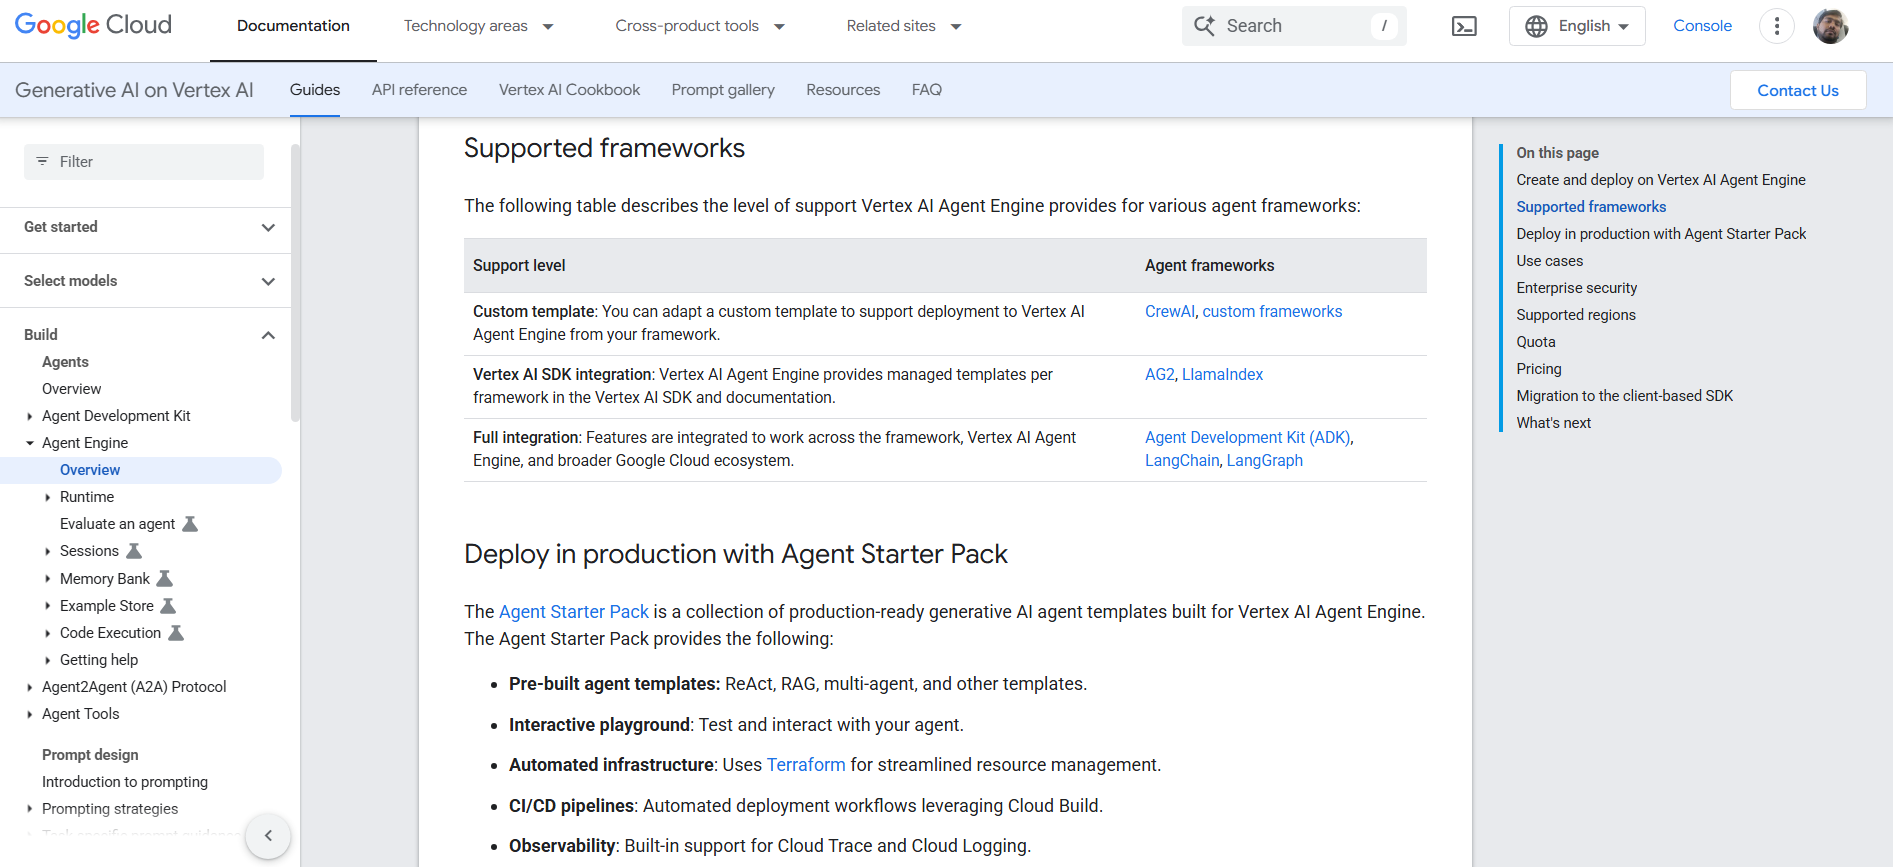

----


## Accelerated deployment
This section describes how to perform a deployment using the [Agent Starter Pack](https://github.com/GoogleCloudPlatform/agent-starter-pack) (ASP) and the ADK command line interface (CLI) tool. This approach uses the ASP tool to apply a project template to your existing project, add deployment artifacts, and prepare your agent project for deployment. These instructions show you how to use ASP to provision a Google Cloud project with services needed for deploying your ADK project, as follows:

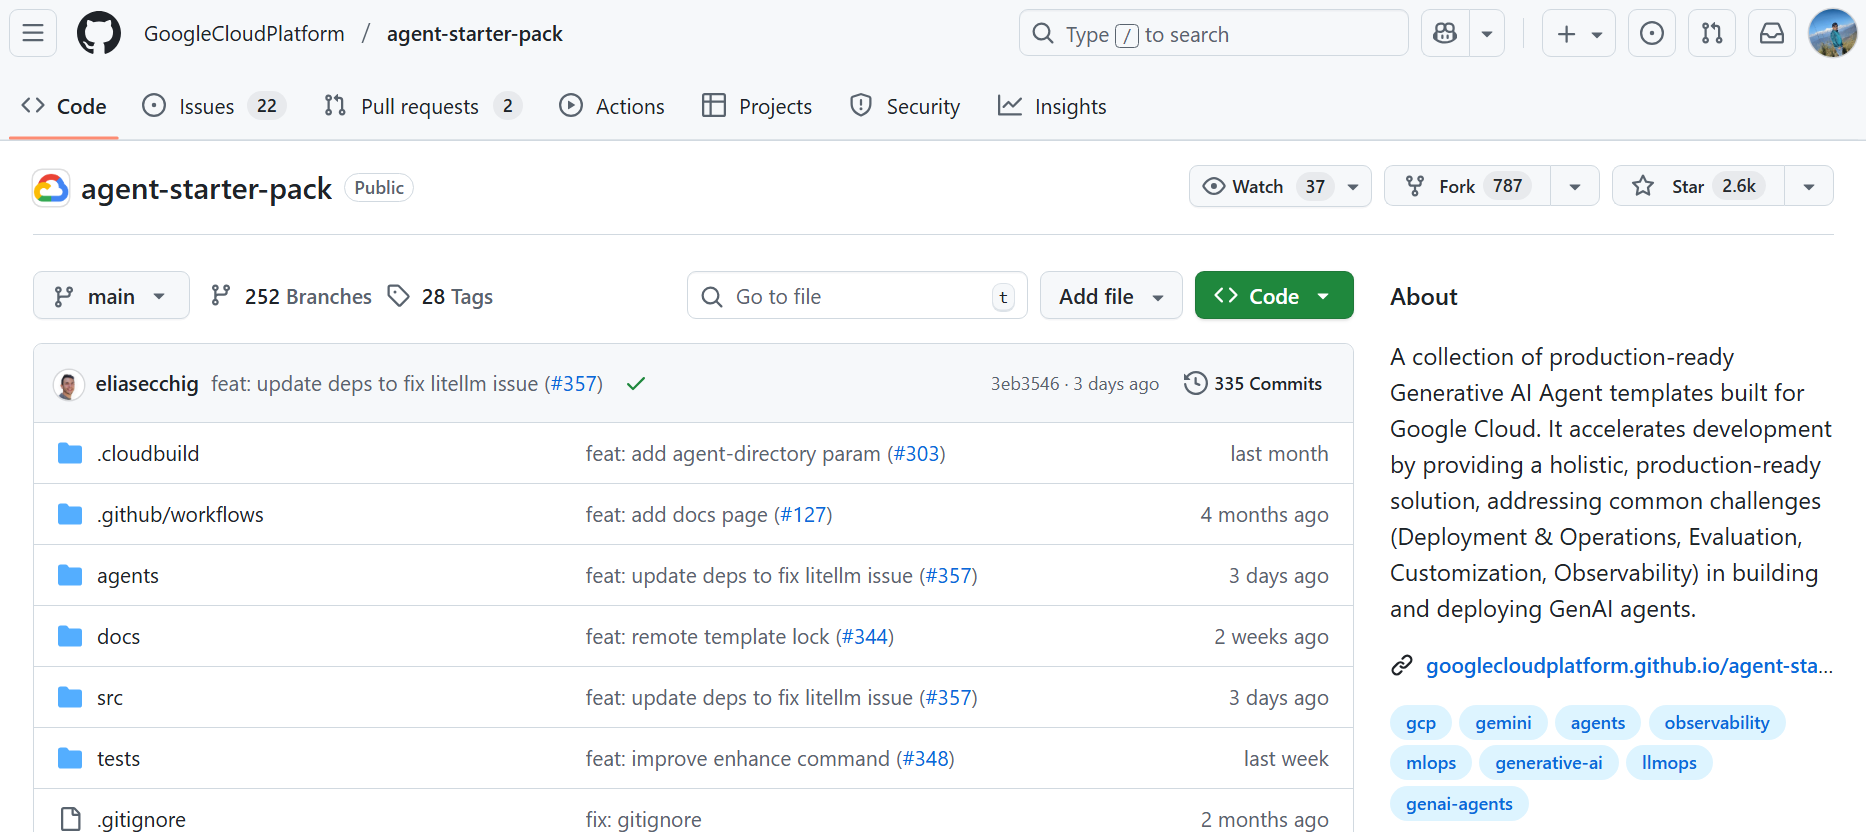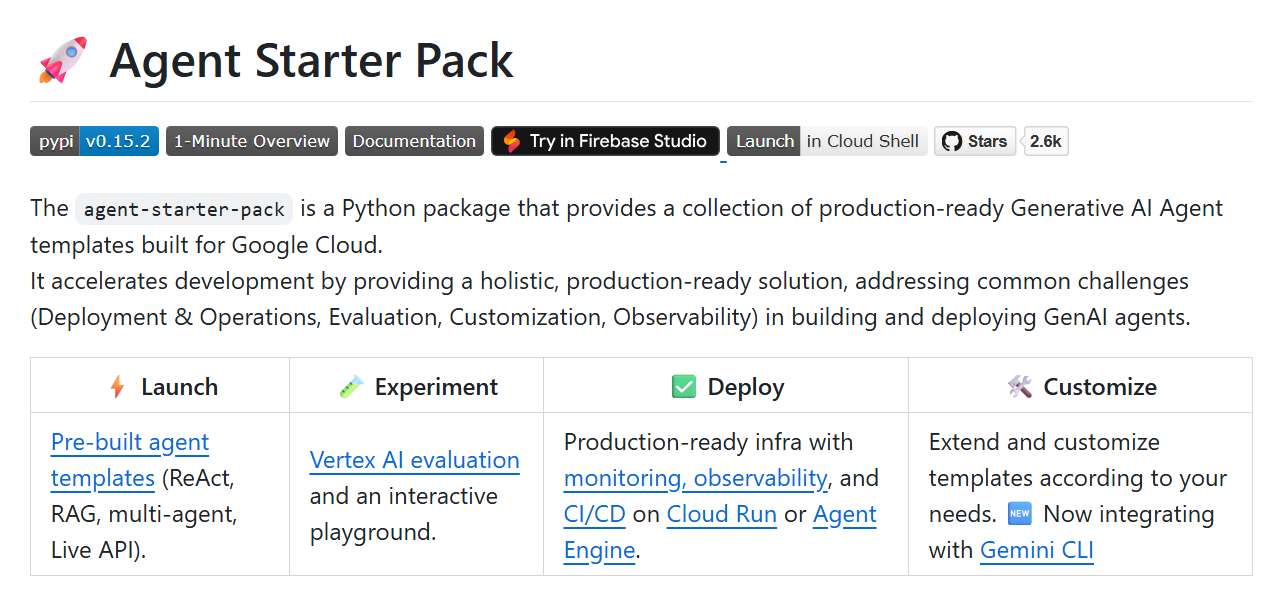

- `Prerequisites`: Setup Google Cloud account, a project, and install required software.
- `Prepare your ADK project`: Modify your existing ADK project files to get ready for deployment.
- `Connect to your Google Cloud project`: Connect your development environment to Google Cloud and your Google Cloud project.
- `Deploy your ADK project`: Provision required services in your Google Cloud project and upload your ADK project code.

> For information on testing a deployed agent, see `Test deployed agent`. For more information on using Agent Starter Pack and its command line tools, see the [CLI reference](https://googlecloudplatform.github.io/agent-starter-pack/cli/enhance.html) and [Development guide](https://googlecloudplatform.github.io/agent-starter-pack/guide/development-guide.html).

#### `CLI Reference`
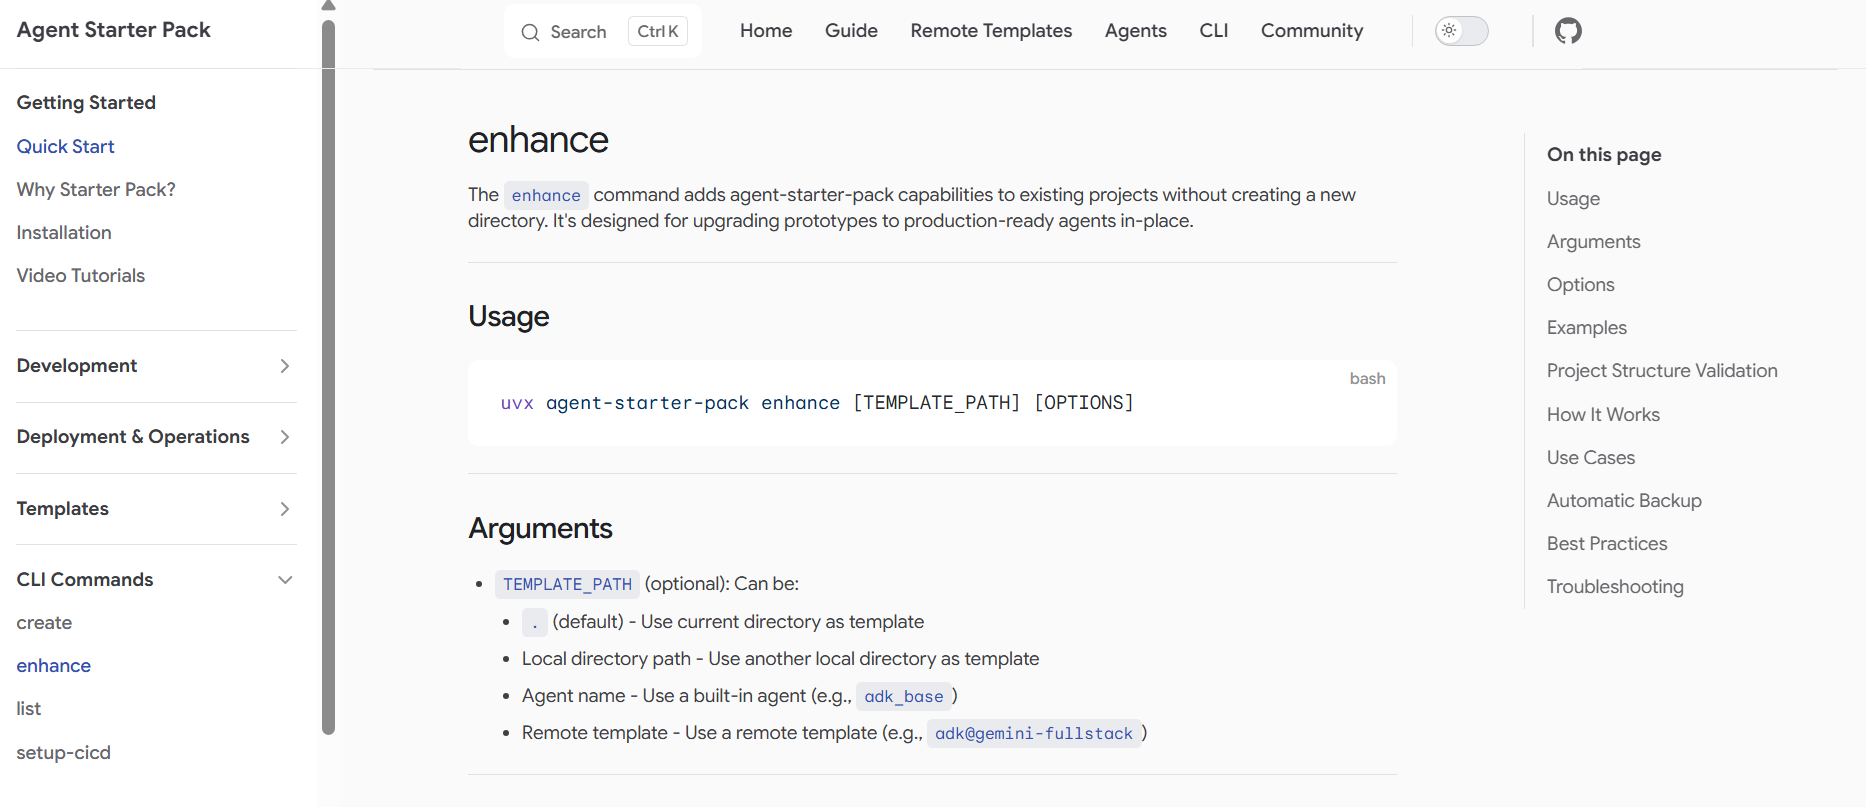

#### `Development Guide`
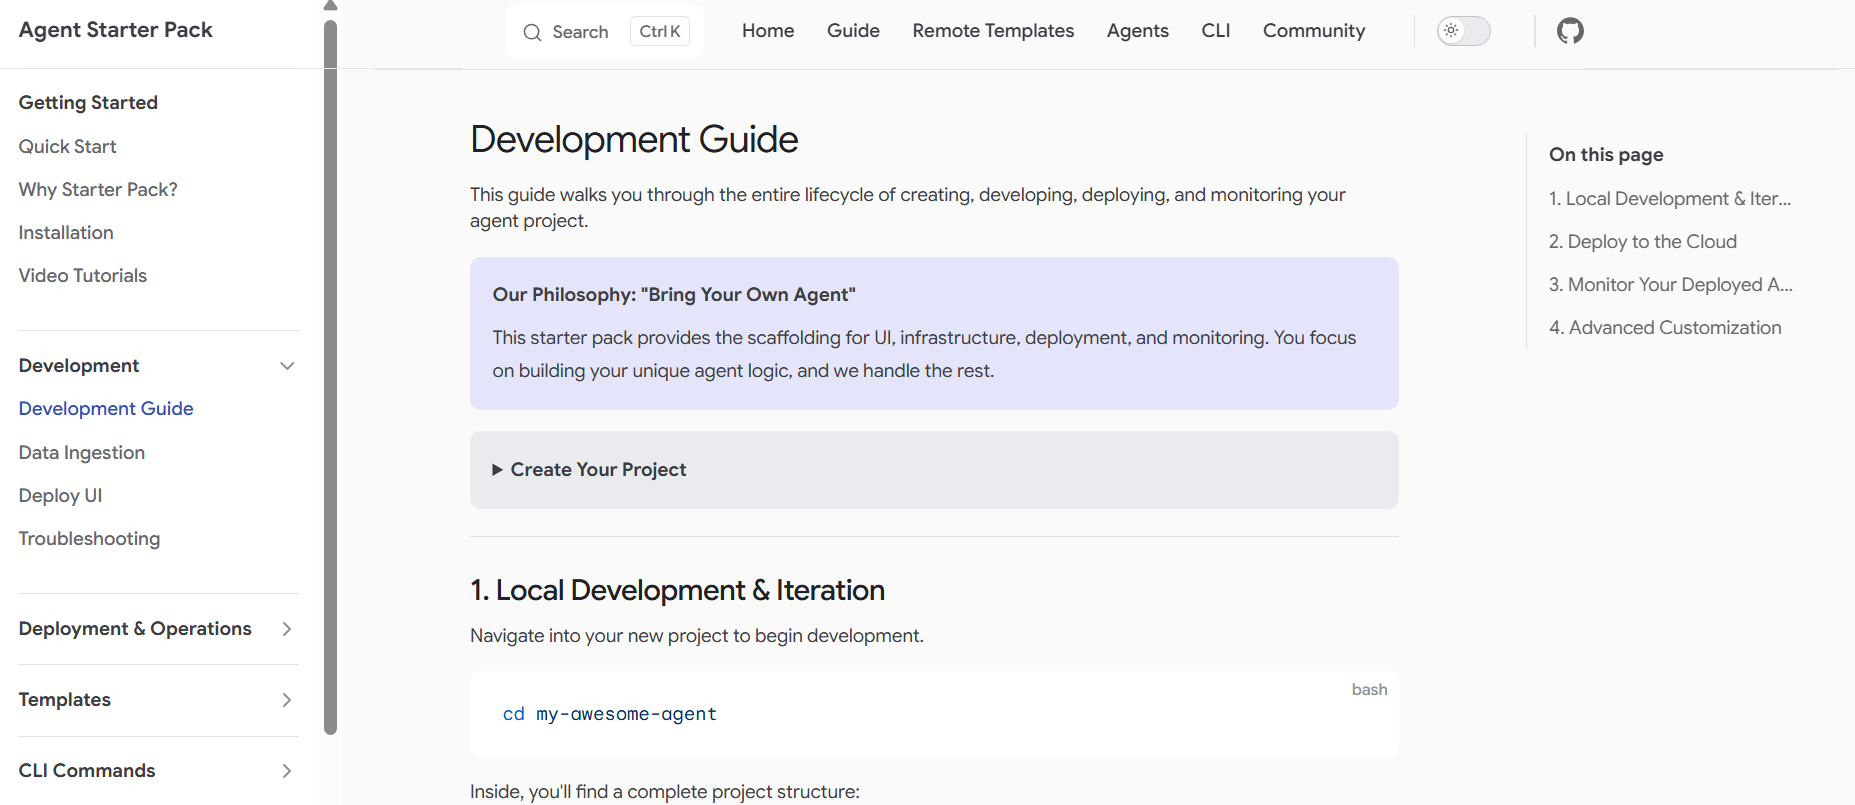

---

### Prerequisites
You need the following resources configured to use this deployment path:

- **Google Cloud account**, with administrator access to:
- **Google Cloud Project**: An empty Google Cloud project with [billing enabled](https://cloud.google.com/billing/docs/how-to/modify-project). For information on creating projects, see [Creating and managing projects](https://cloud.google.com/resource-manager/docs/creating-managing-projects).
- **Python Environment**: A Python version between 3.9 and 3.13.
- **UV Tool**: Manage Python development environment and running ASP tools. For installation details, see [Install UV](https://docs.astral.sh/uv/getting-started/installation/).
- **Google Cloud CLI tool**: The gcloud command line interface. For installation details, see [Google Cloud Command Line Interface](https://cloud.google.com/sdk/docs/install).
- **Make tool**: Build automation tool. This tool is part of most Unix-based systems, for installation details, see the [Make tool](https://www.gnu.org/software/make/) documentation.
- **Terraform**: Infrastructure and services deployment on Google Cloud. For installation details, see [Install Terraform](https://developer.hashicorp.com/terraform/install).

#### `Enable, disable, or change billing for a project`
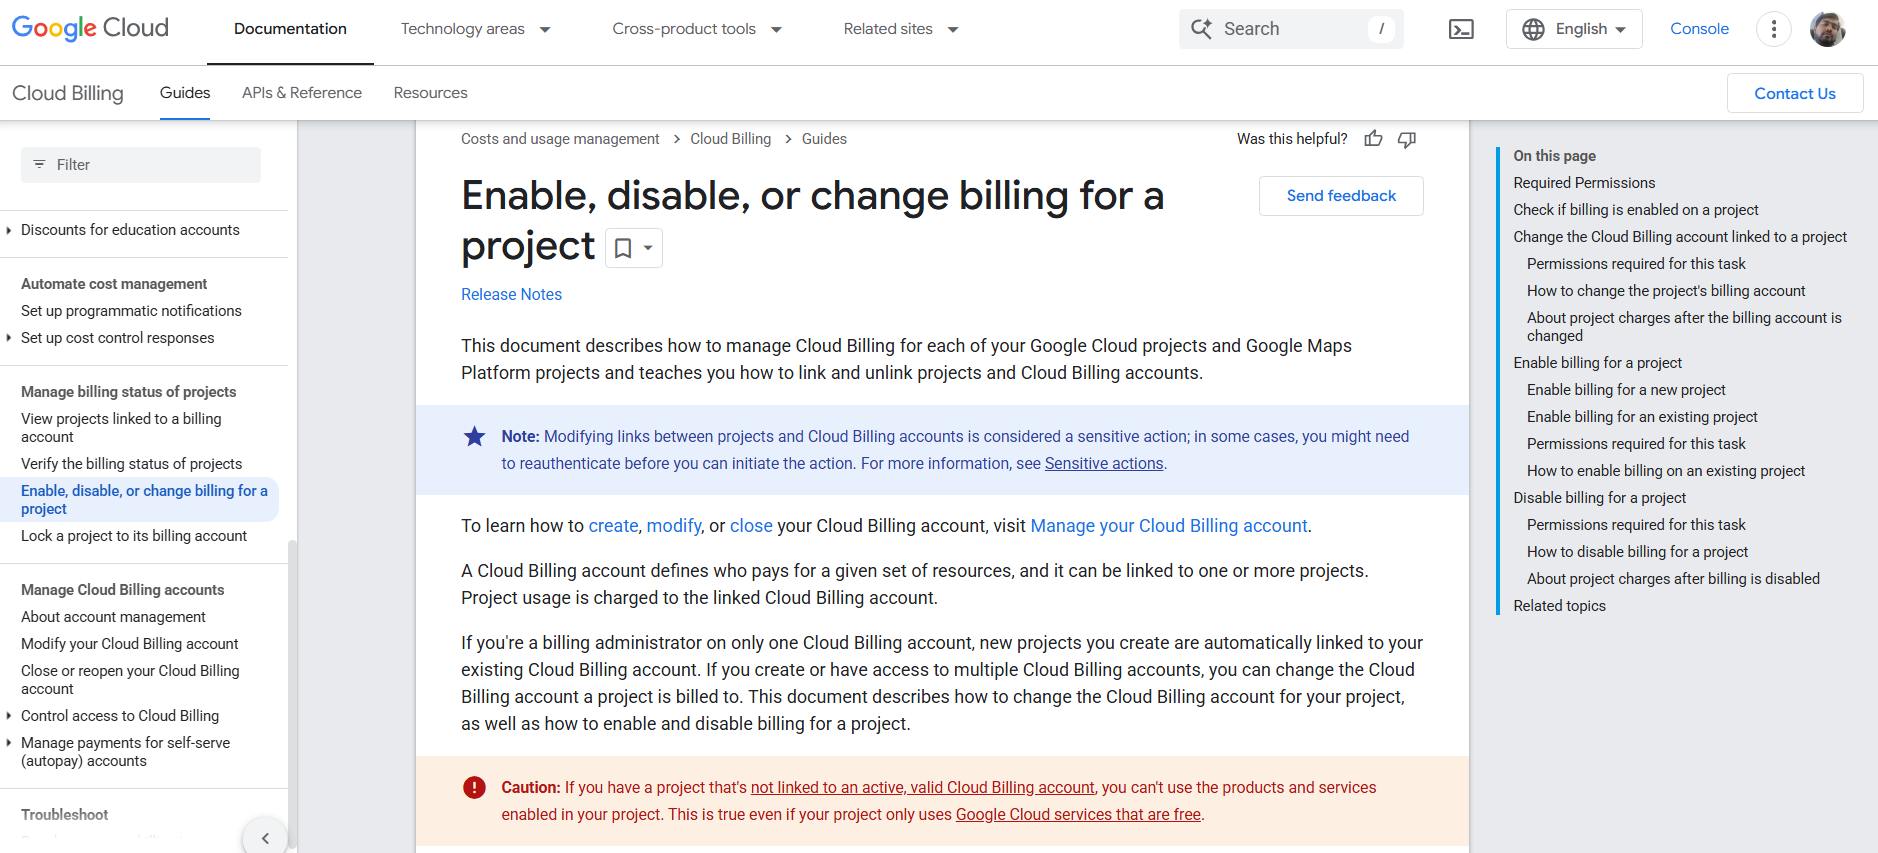

#### `Creating and managing projects`
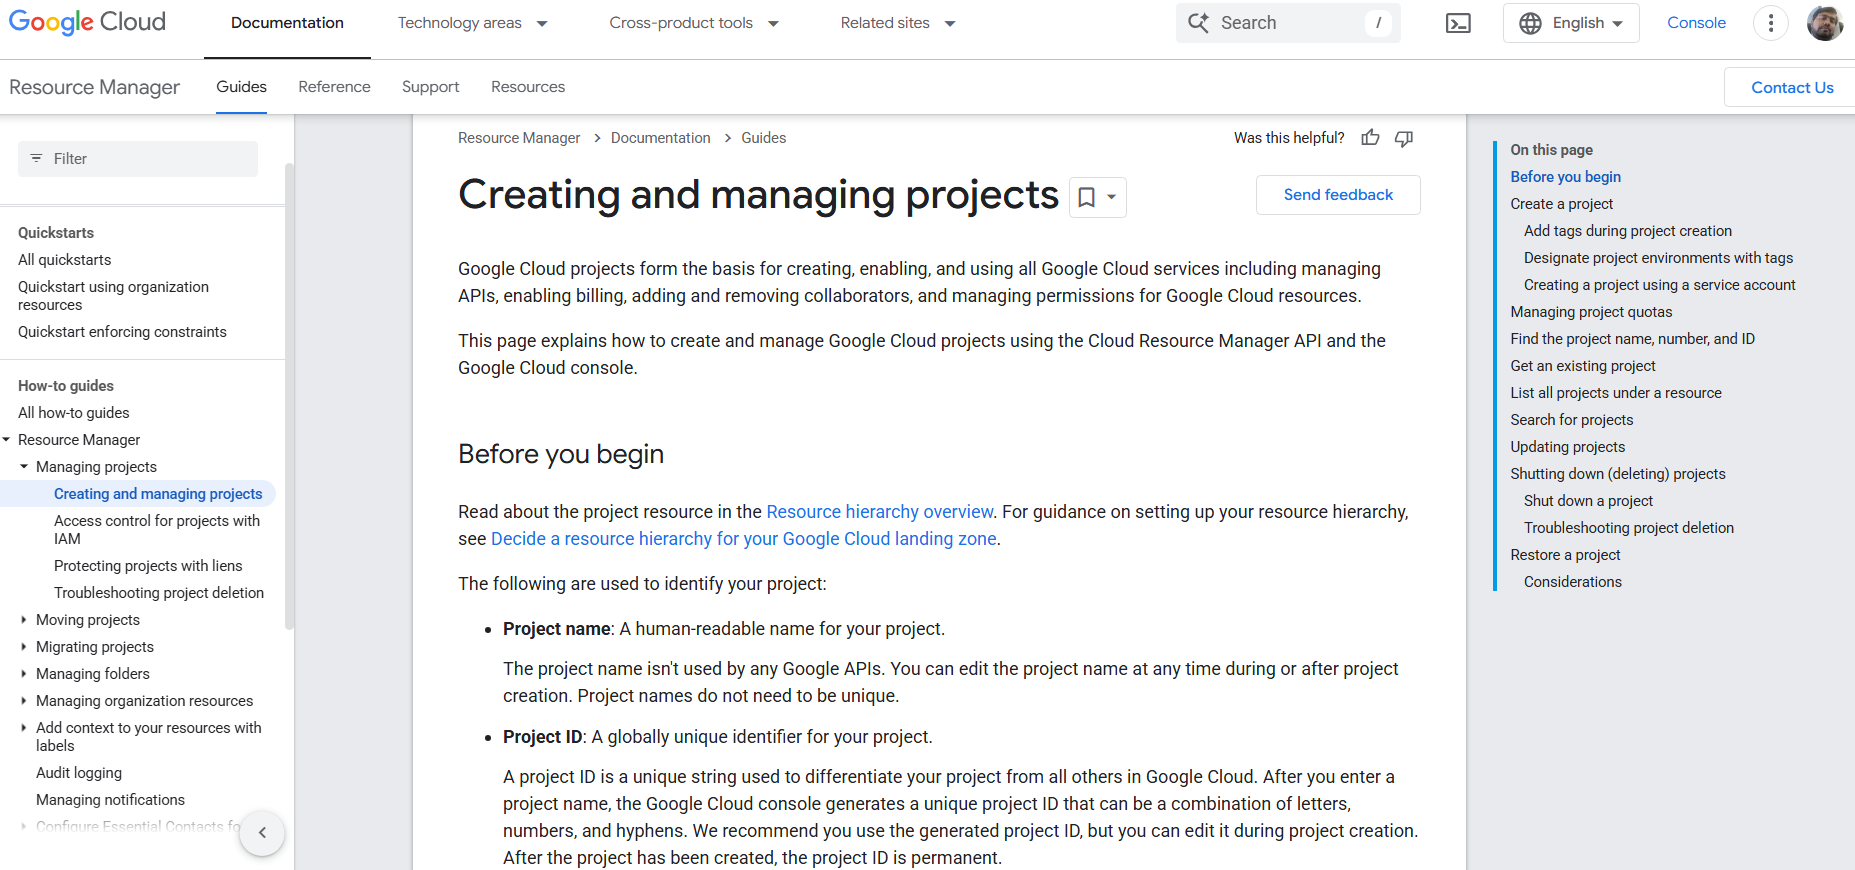

#### `Install UV`
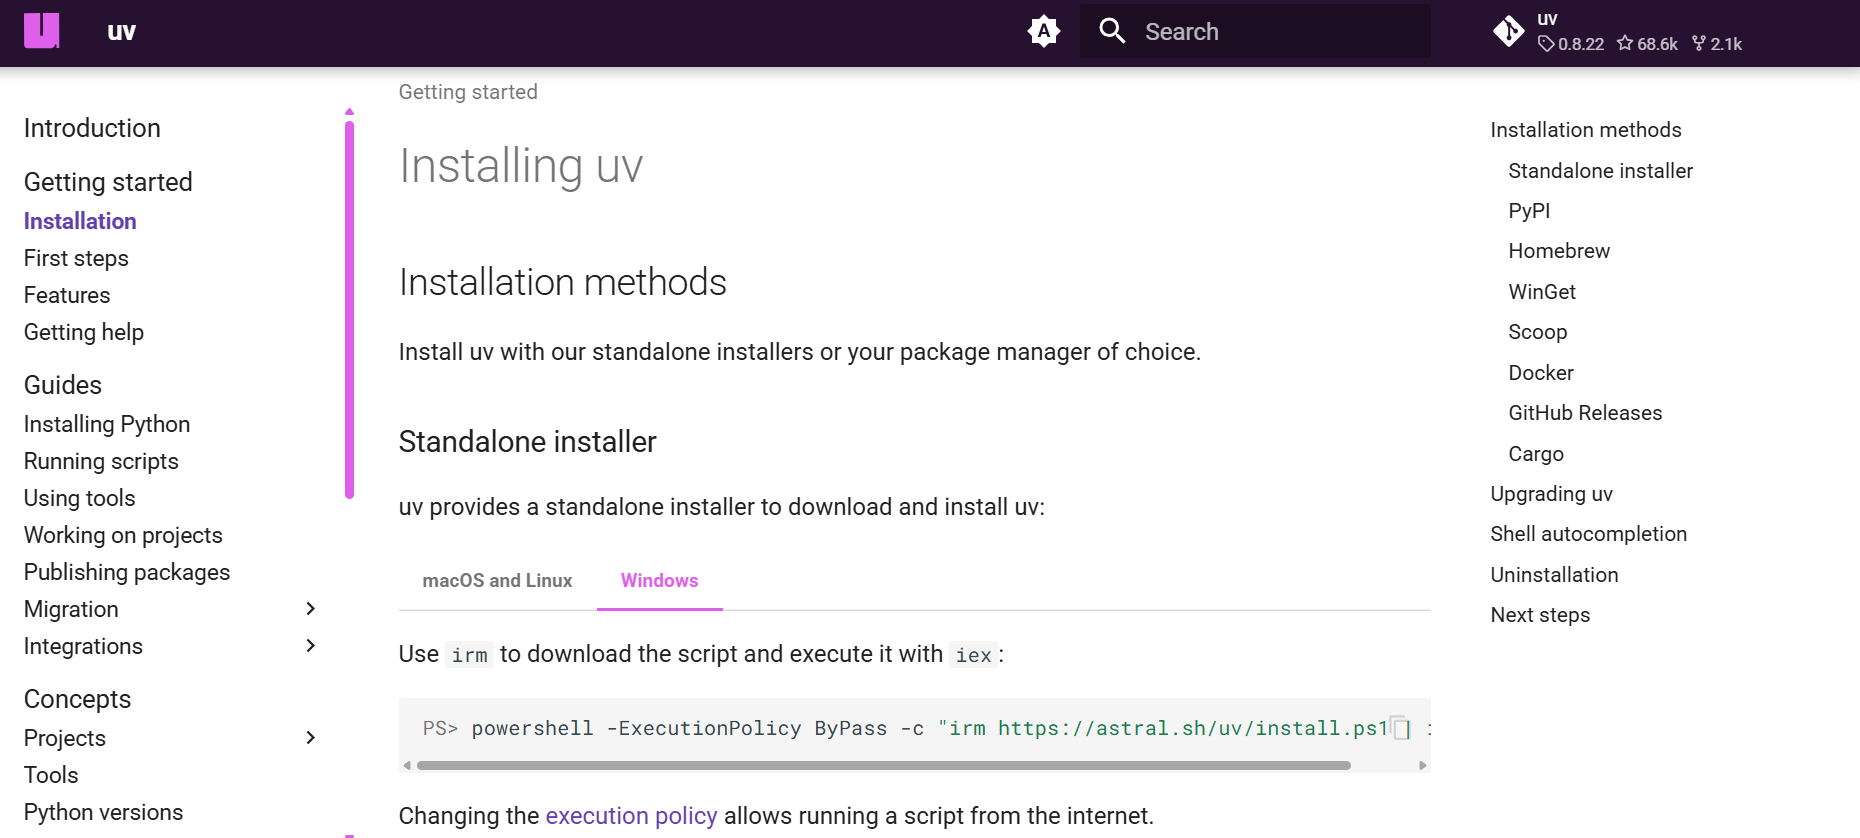

#### `Google Cloud Command Line Interface`
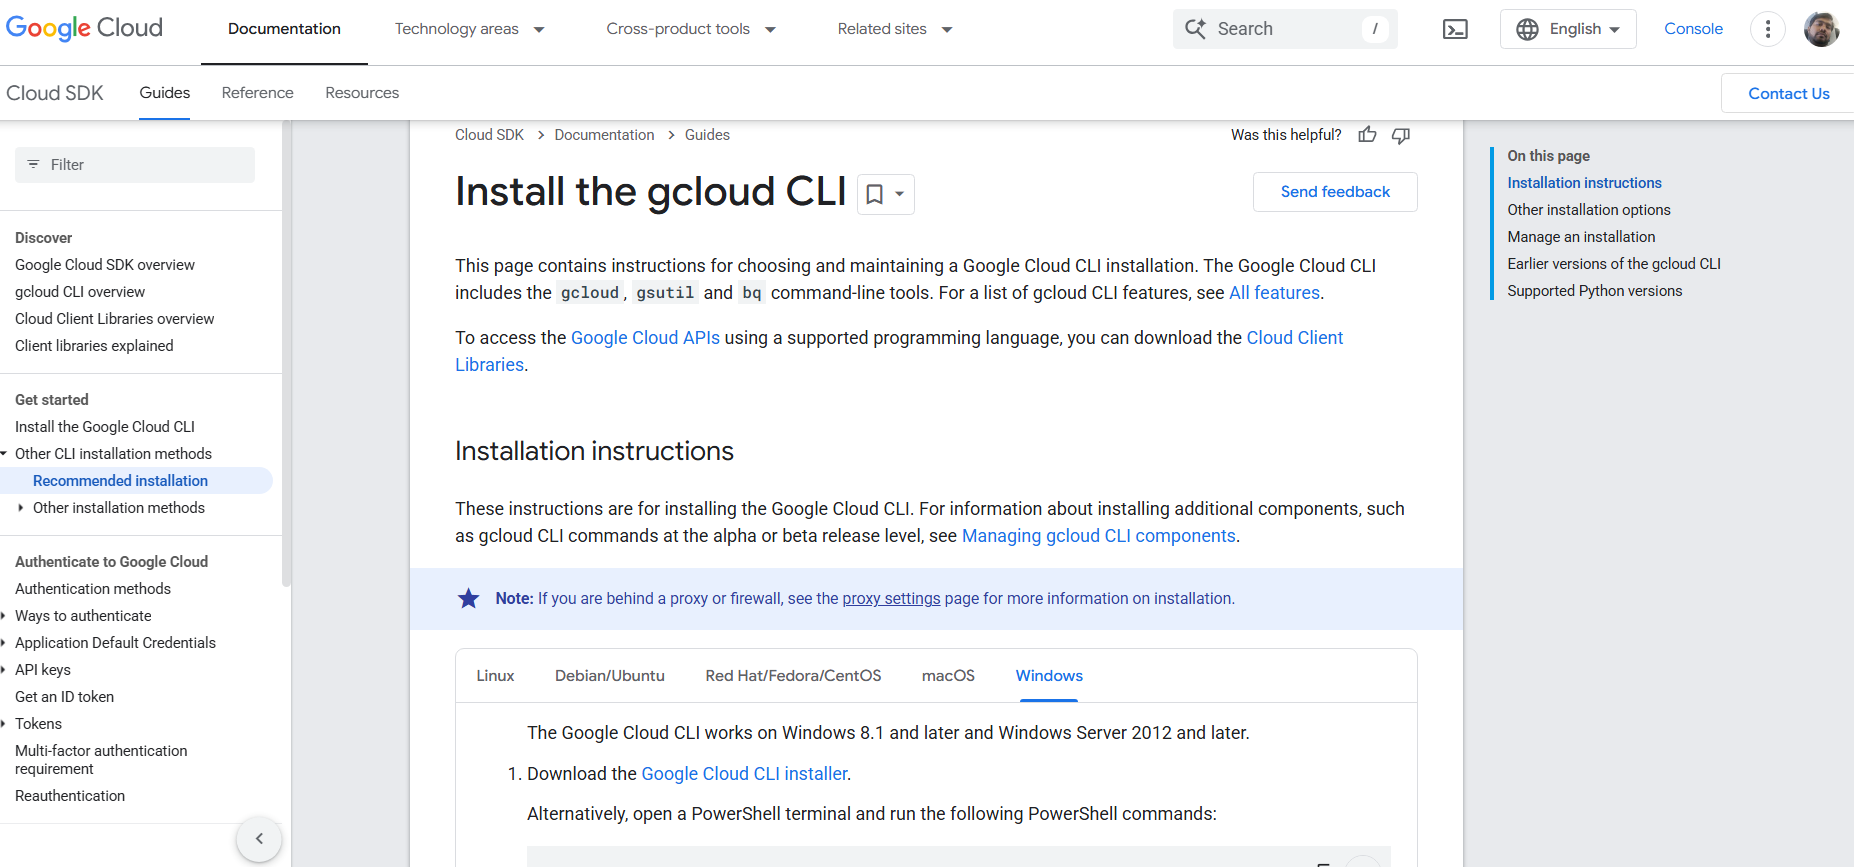

#### `Make Tool`
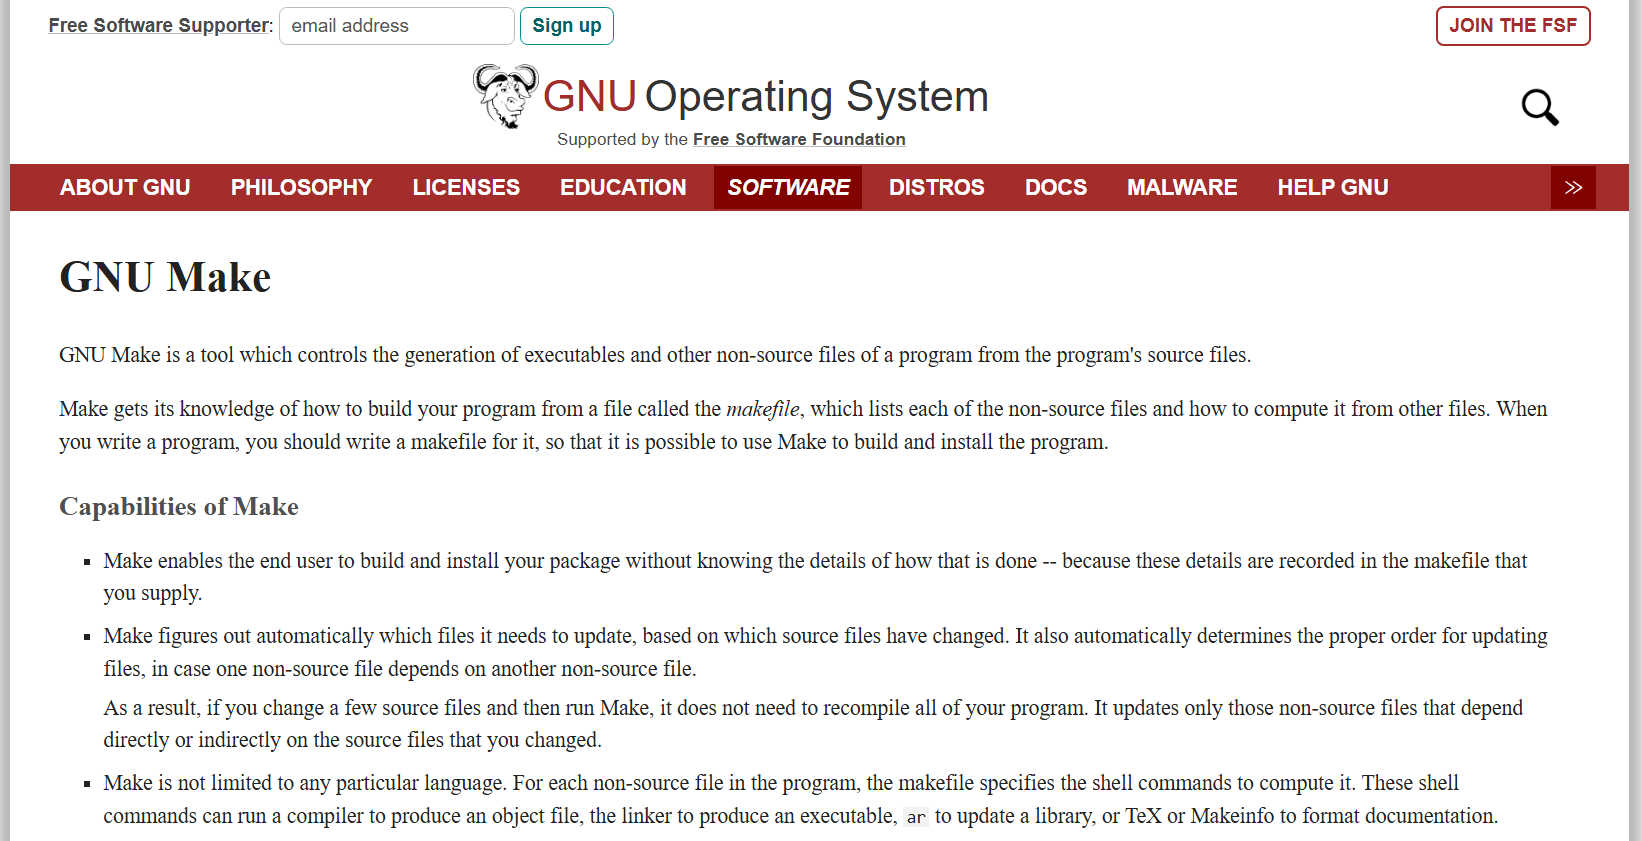

#### `Install Terraform`
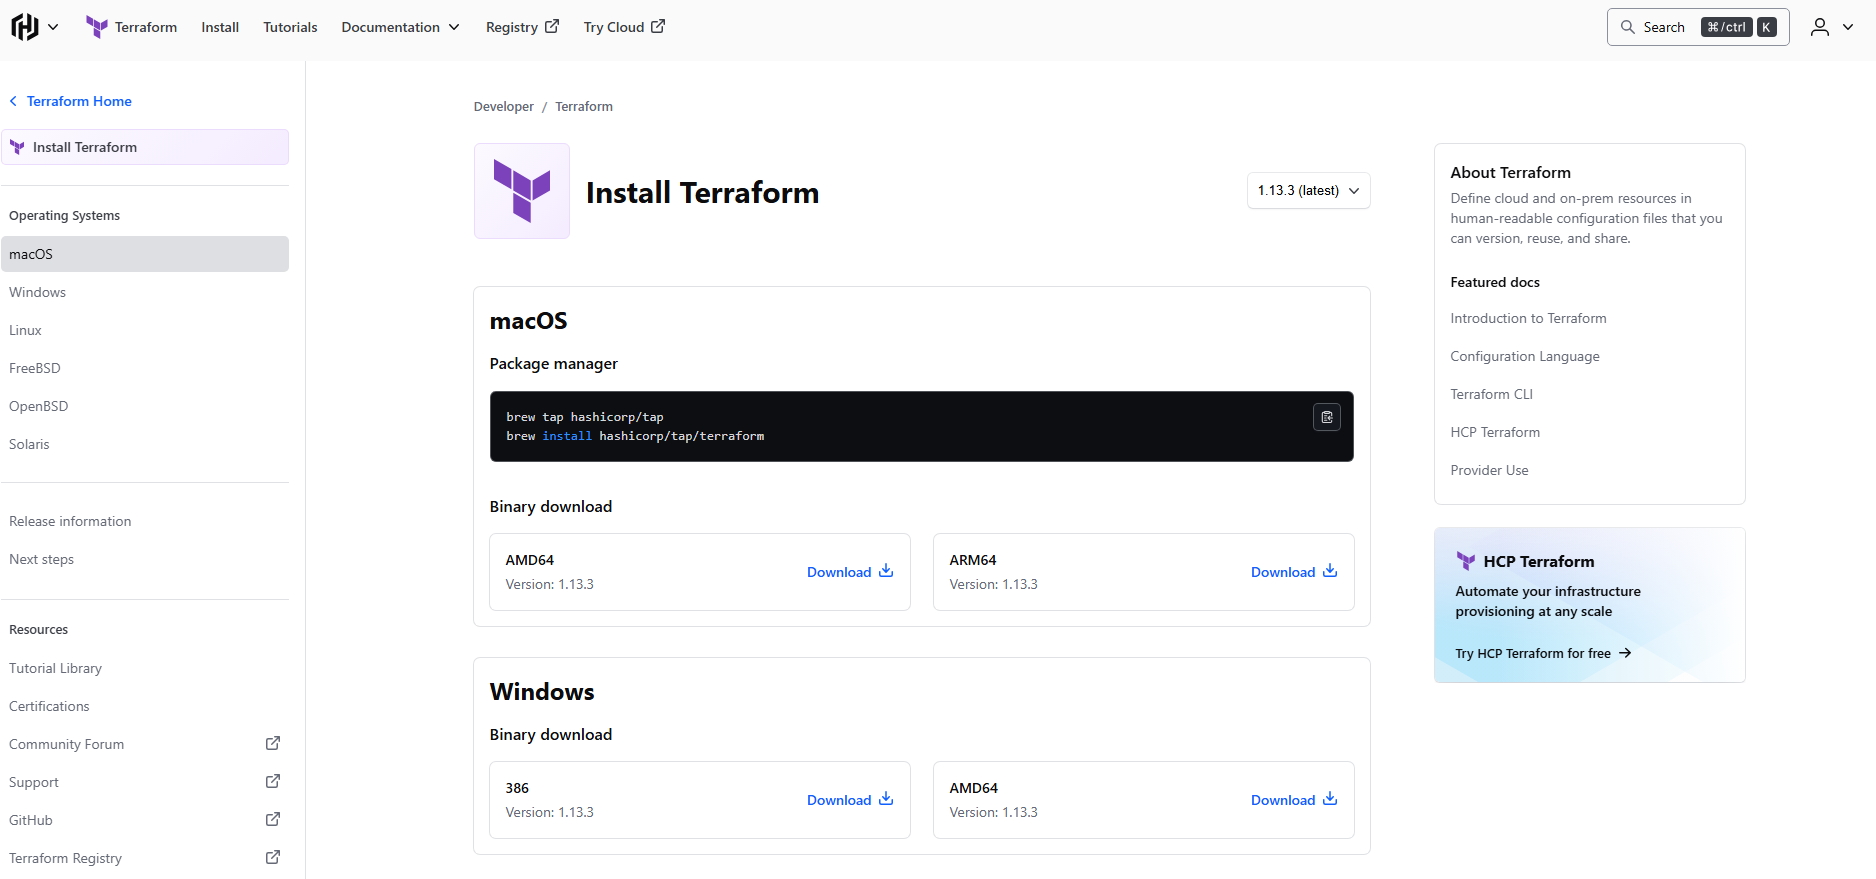

----

### Prepare your ADK project
When you deploy an ADK project to Agent Engine, you need some additional files to support the deployment operation. The following ASP command backs up your project and then adds files to your project for deployment purposes.

These instructions assume you have an existing ADK project that you are modifying for deployment. If you do not have an ADK project, or want to use a test project, complete the Python [Quickstart](https://google.github.io/adk-docs/get-started/quickstart/) guide, which creates a [multi_tool_agent](https://github.com/google/adk-docs/tree/main/examples/python/snippets/get-started/multi_tool_agent) project. The following instructions use the multi_tool_agent project as an example.

To prepare your ADK project for deployment to Agent Engine:
1. In a terminal window of your development environment, navigate to the root directory of your project, for example:
    ```bash
    cd multi_tool_agent/
    ```
2. Run the ASP `enhance` command to add the needed files required for deployment into your project.
    ```bash
    uvx agent-starter-pack enhance --adk -d agent_engine
    ```
3. Follow the instructions from the ASP tool. In general, you can accept the default answers to all questions. However for the GCP region, option, make sure you select one of the [supported regions for Agent Engine](https://cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/overview#supported-regions).

When you successfully complete this process, the tool shows the following message:
```bash
> Success! Your agent project is ready.
```
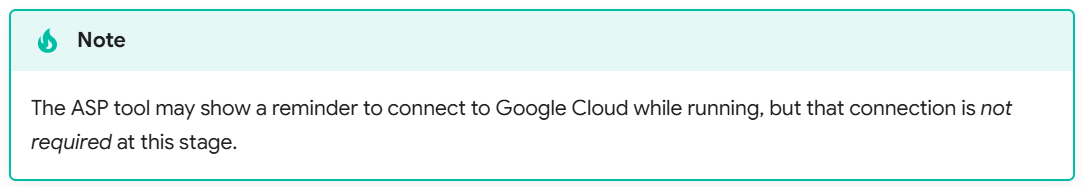

For more information about the changes ASP makes to your ADK project, see [Changes to your ADK project](https://google.github.io/adk-docs/deploy/agent-engine/#adk-asp-changes).

#### `Quickstart`
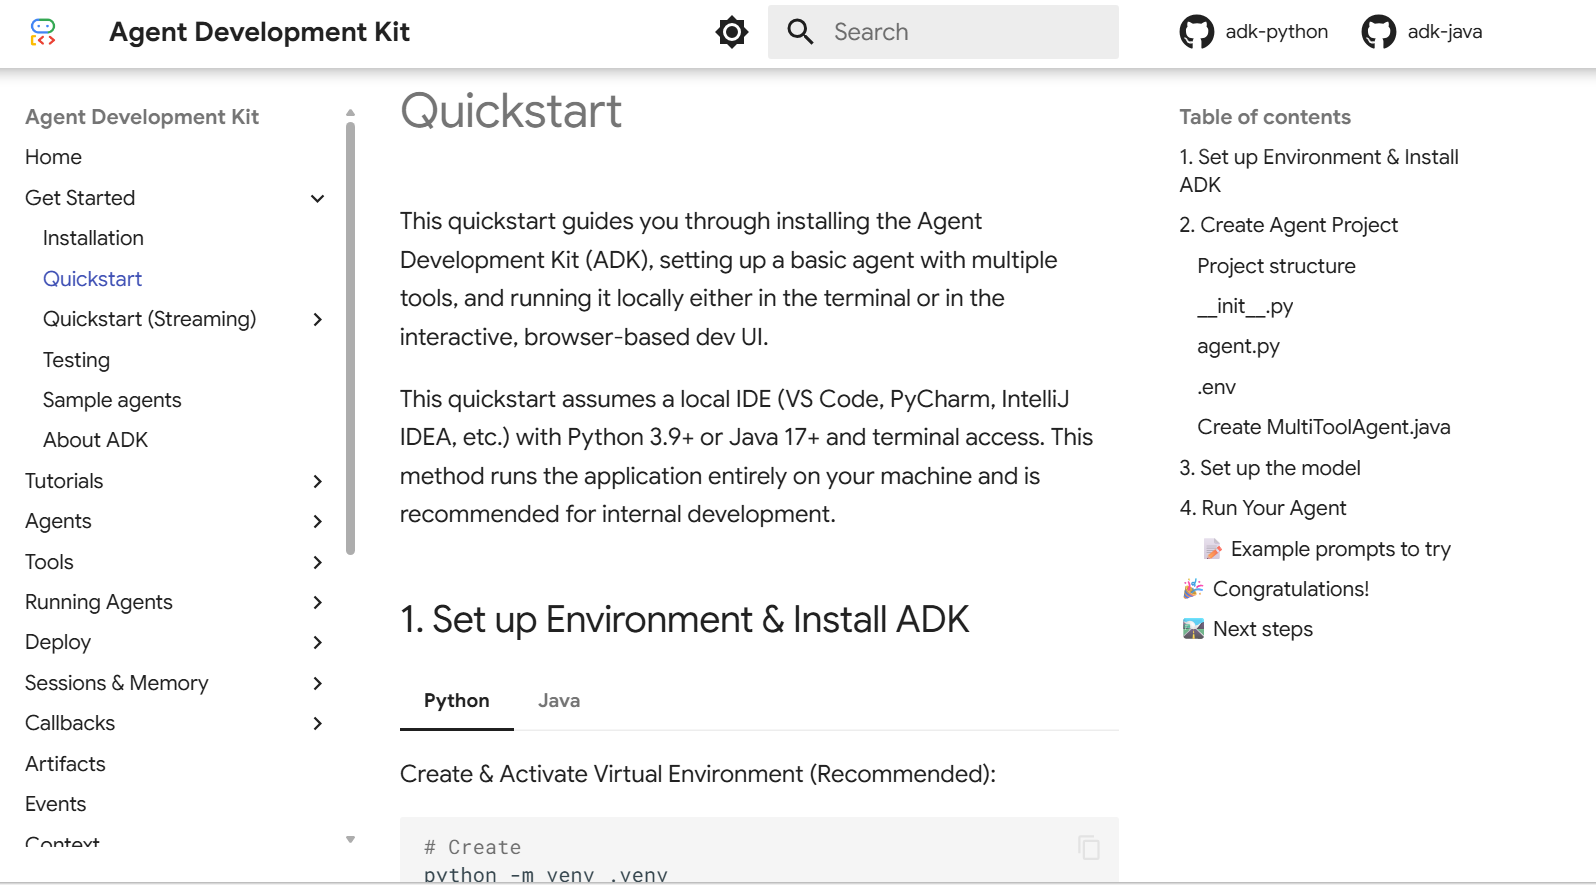

#### `multi_tool_agent`
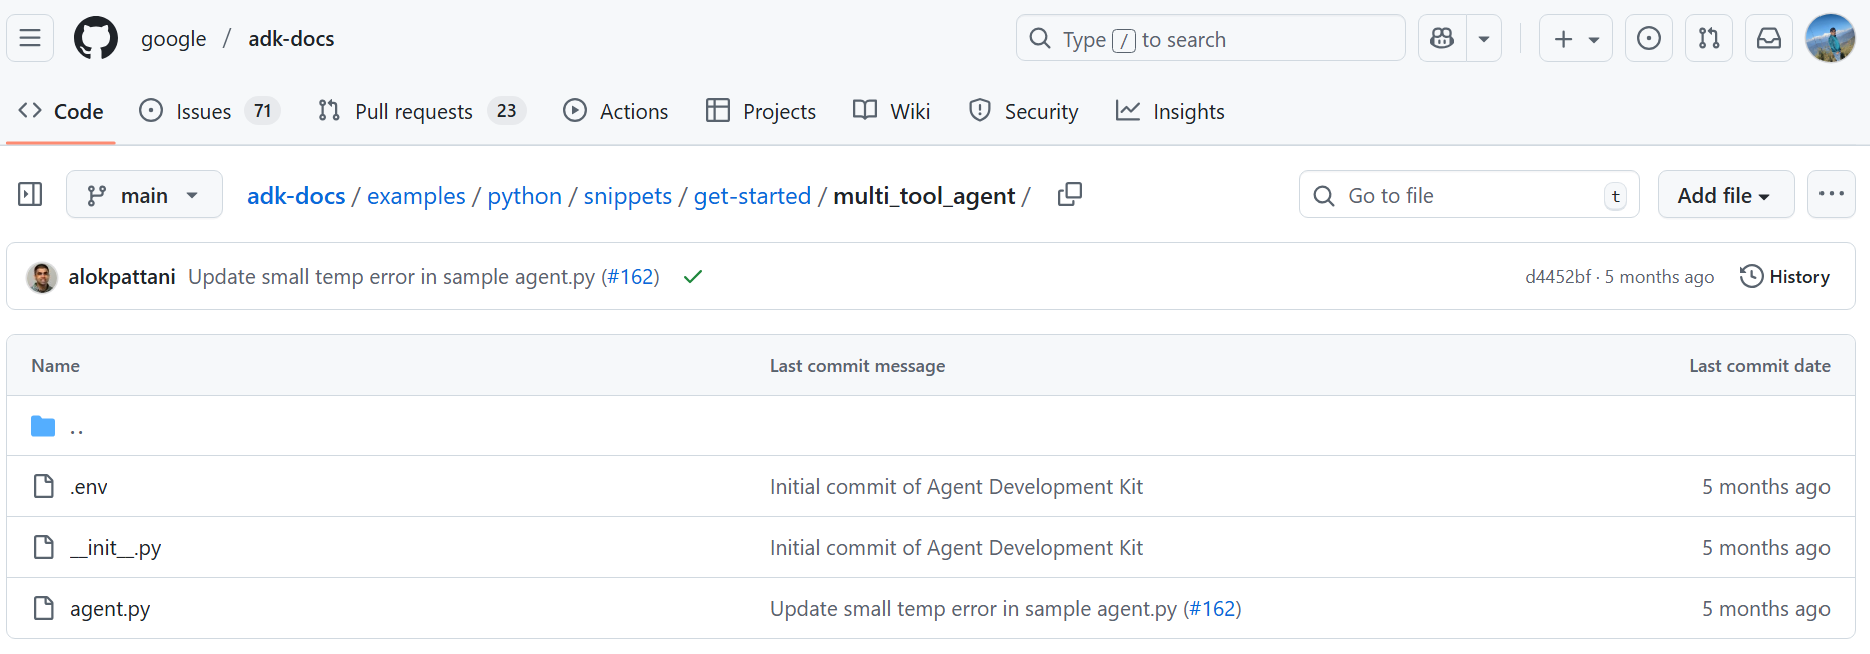

#### `supported regions for Agent Engine`
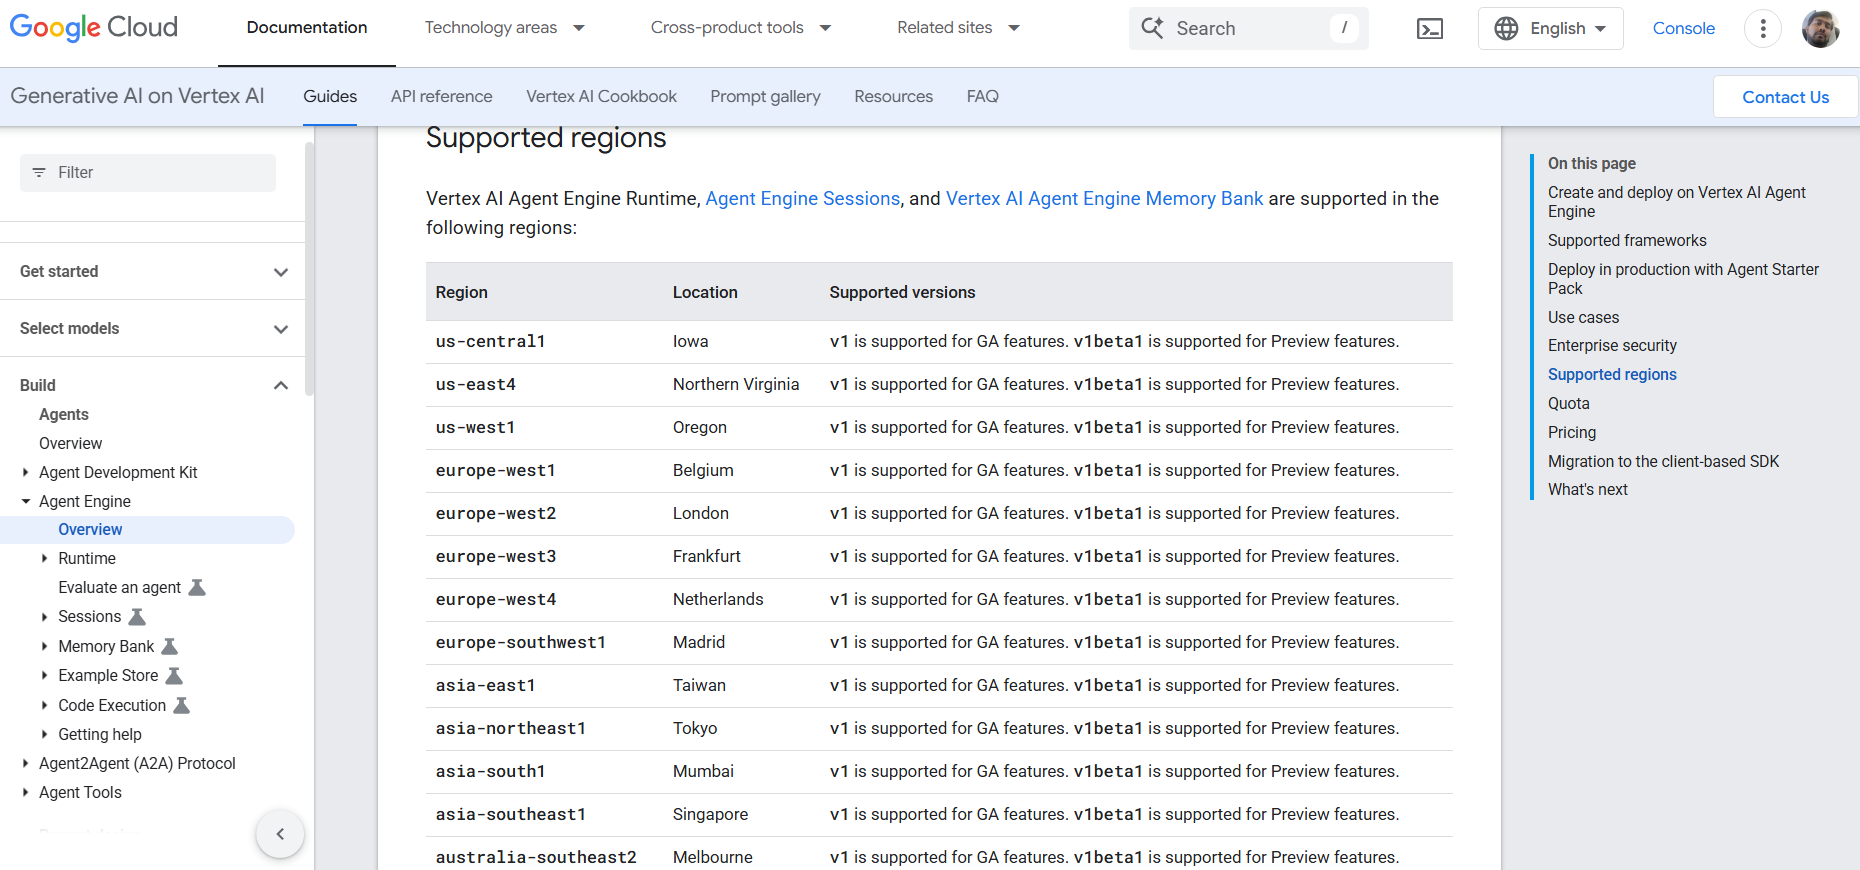

#### `Changes to your ADK project`
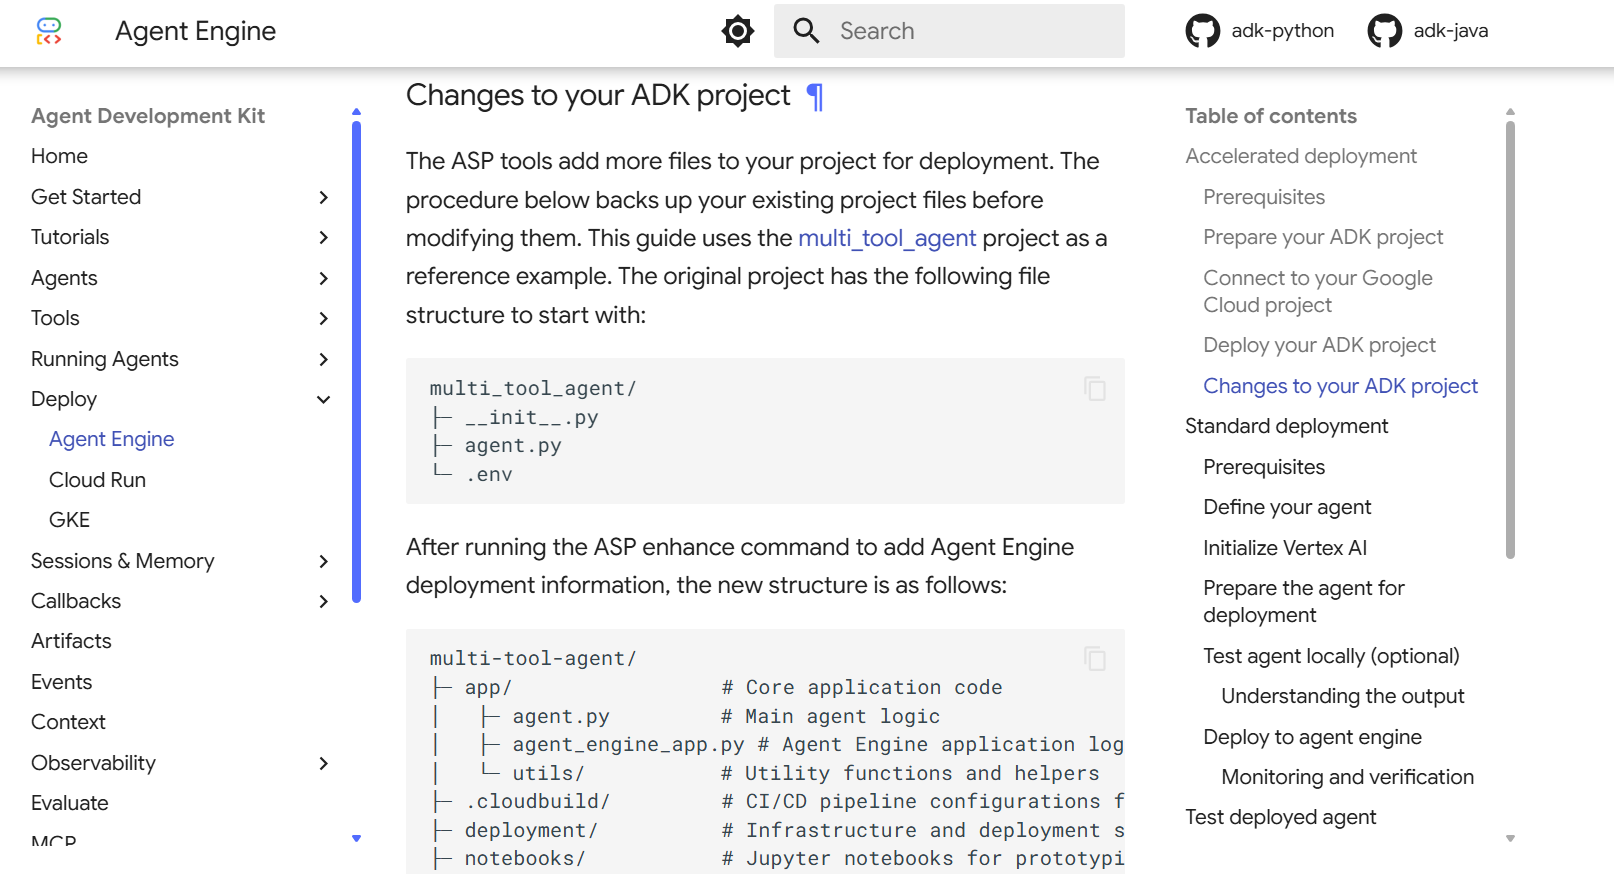

----

### Connect to your Google Cloud project
Before you deploy your ADK project, you must connect to `Google Cloud` and your project. After logging into your `Google Cloud account`, you should verify that your deployment target project is visible from your account and that it is configured as your current project.

To connect to Google Cloud and list your project:
1. In a terminal window of your development environment, login to your Google Cloud account:

    ```bash
    gcloud auth application-default login
    ```
1. Set your target project using the Google Cloud Project ID:

    ```bash
    gcloud config set project your-project-id-xxxxx
    ```
1. Verify your Google Cloud target project is set:

    ```bash
    gcloud config get-value project
    ```
> Once you have successfully connected to Google Cloud and set your Cloud Project ID, you are ready to deploy your ADK project files to Agent Engine.

----

### Deploy your ADK project
When using the ASP tool, you deploy in stages. In the first stage, you run a make command that provisions the services needed to run your ADK workflow on Agent Engine. In the second stage, your project code is uploaded to the Agent Engine service and the agent project is executed.

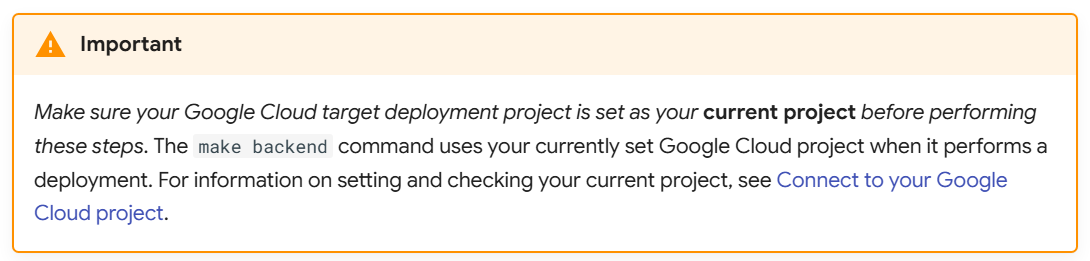

To deploy your ADK project to Agent Engine in your Google Cloud project:
1. In a terminal window of your development environment, navigate to the root directory of your project, for example: cd multi_tool_agent/
1. Provision a development environment, including logging, services accounts, storage, and Vertex AI API by running the following ASP make command:
    ```bash
    make setup-dev-env
    ```
1. Deploy the code from the updated local project into the Google Cloud development environment, by running the following ASP make command:
    ```bash
    make backend
    ```
Once this process completes successfully, you should be able to interact with the agent running on Google Cloud Agent Engine. For details on testing the deployed agent, see the next section.

Once this process completes successfully, you should be able to interact with the agent running on Google Cloud Agent Engine. For details on testing the deployed agent, see [Test deployed agent](https://google.github.io/adk-docs/deploy/agent-engine/#test-deployment).

#### `Test Deployed Agent`
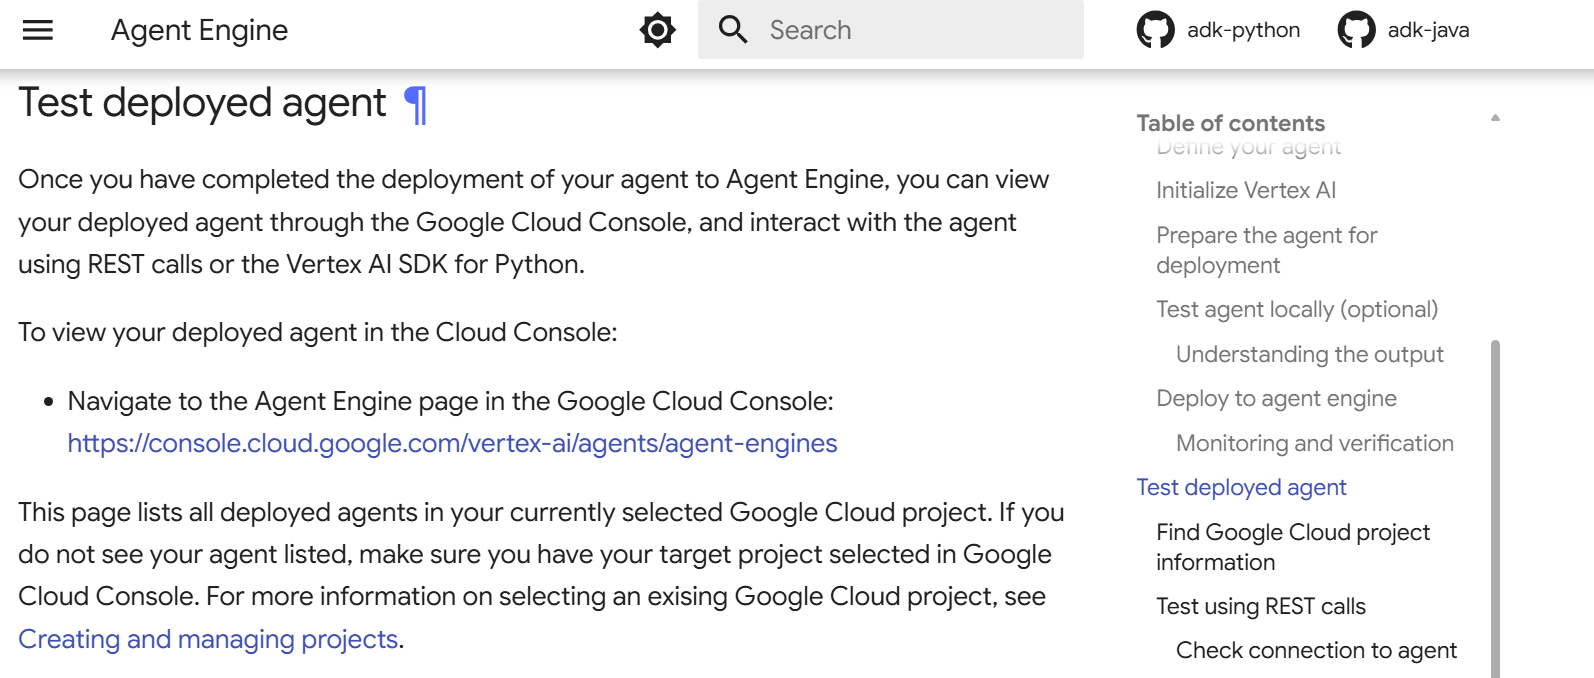

----

### Changes to your ADK project
The ASP tools add more files to your project for deployment. The procedure below backs up your existing project files before modifying them. This guide uses the multi_tool_agent project as a reference example. The original project has the following file structure to start with:

```
multi_tool_agent/
├─ __init__.py
├─ agent.py
└─ .env
```

After running the ASP enhance command to add Agent Engine deployment information, the new structure is as follows:

```
multi-tool-agent/
├─ app/                 # Core application code
│   ├─ agent.py         # Main agent logic
│   ├─ agent_engine_app.py # Agent Engine application logic
│   └─ utils/           # Utility functions and helpers
├─ .cloudbuild/         # CI/CD pipeline configurations for Google Cloud Build
├─ deployment/          # Infrastructure and deployment scripts
├─ notebooks/           # Jupyter notebooks for prototyping and evaluation
├─ tests/               # Unit, integration, and load tests
├─ Makefile             # Makefile for common commands
├─ GEMINI.md            # AI-assisted development guide
└─ pyproject.toml       # Project dependencies and configuration
```

> See the README.md file in your updated ADK project folder for more information. For more information on using Agent Starter Pack, see the [Development guide](https://googlecloudplatform.github.io/agent-starter-pack/guide/development-guide.html).

---

### Standard deployment
This section describes how to perform a deployment to Agent Engine step-by-step. These instructions are more appropriate if you want to carefully manage your deployment settings, or are modifying an existing deployment with Agent Engine.

#### Prerequisites
These instructions assume you have already defined an ADK project. If you do not have an ADK project, see the instructions for creating a test project in [Define your agent](https://google.github.io/adk-docs/deploy/agent-engine/#define-your-agent). <br><br>
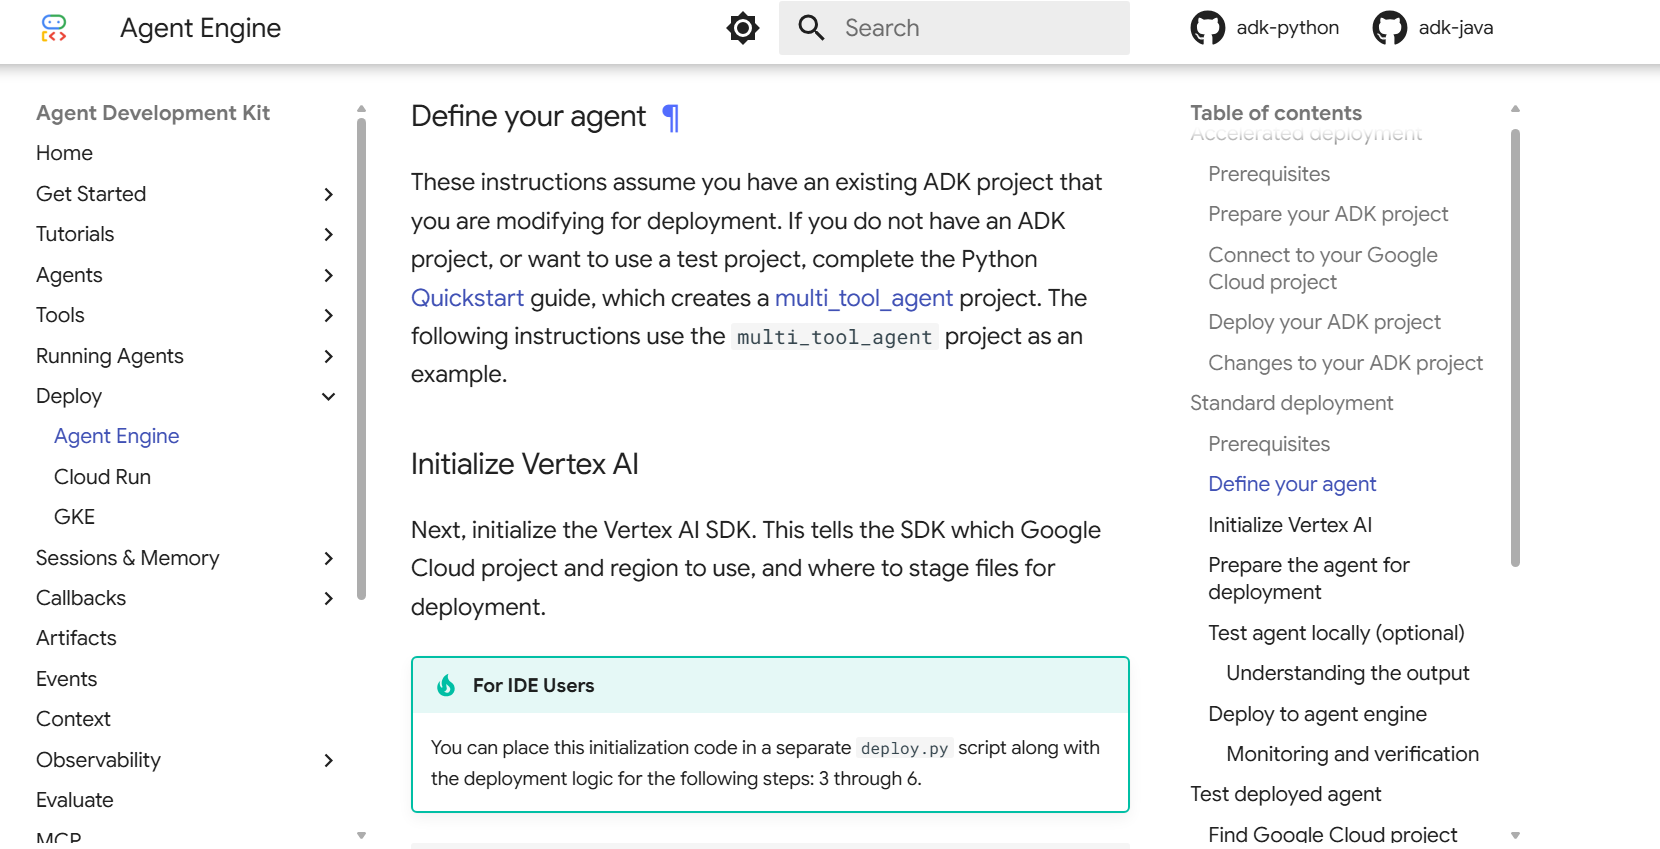

Before starting deployment procedure, ensure you have the following:

1. **Google Cloud Project**: A Google Cloud project with the [Vertex AI API enabled](https://console.cloud.google.com/apis/enableflow;apiid=aiplatform.googleapis.com?project=gen-lang-client-0634579487). <br><br> 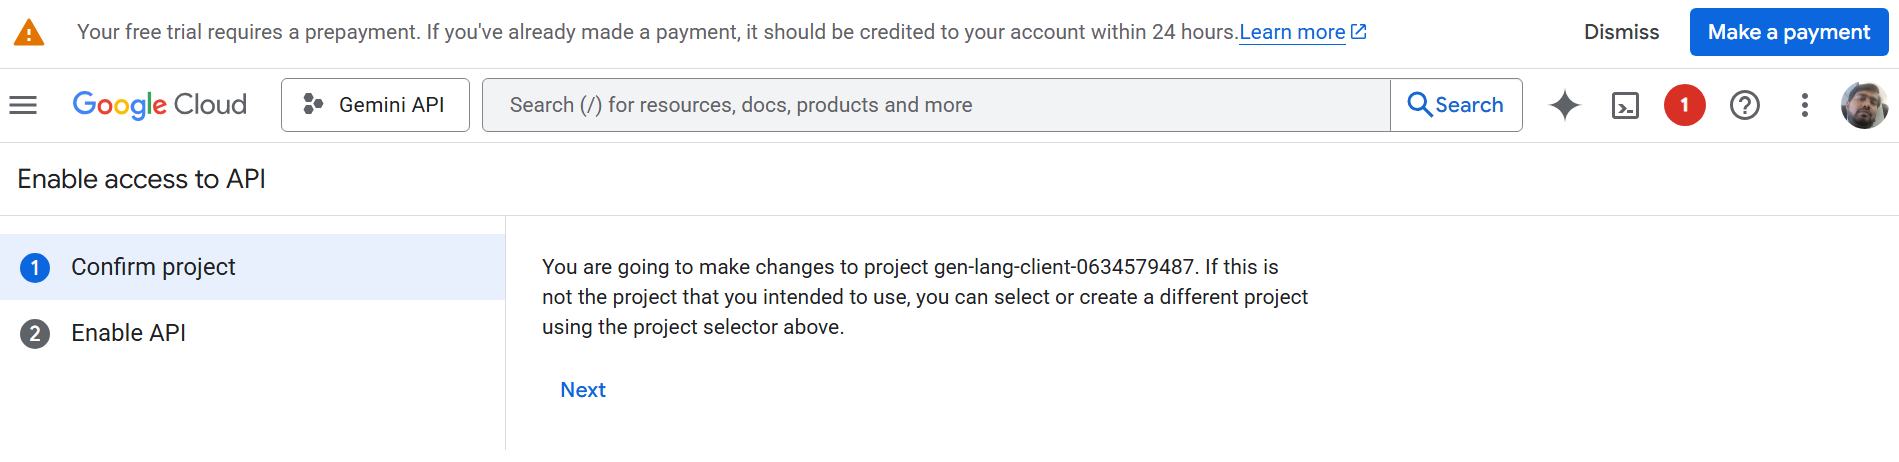

1. **Authenticated gcloud CLI**: You need to be authenticated with Google Cloud. Run the following command in your terminal:
    ```bash
    gcloud auth application-default login
    ```
1. **Google Cloud Storage (GCS) Bucket**: Agent Engine requires a GCS bucket to stage your agent's code and dependencies for deployment. If you don't have a bucket, create one by following the instructions here.
1. **Python Environment**: A Python version between 3.9 and 3.13.
1. **Install Vertex AI SDK**: Agent Engine is part of the Vertex AI SDK for Python. For more information, you can review the [Agent Engine quickstart documentation](https://cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/quickstart).
    ```bash
    pip install google-cloud-aiplatform[adk,agent_engines]>=1.111
    ```
#### `Agent Engine quickstart documentation`
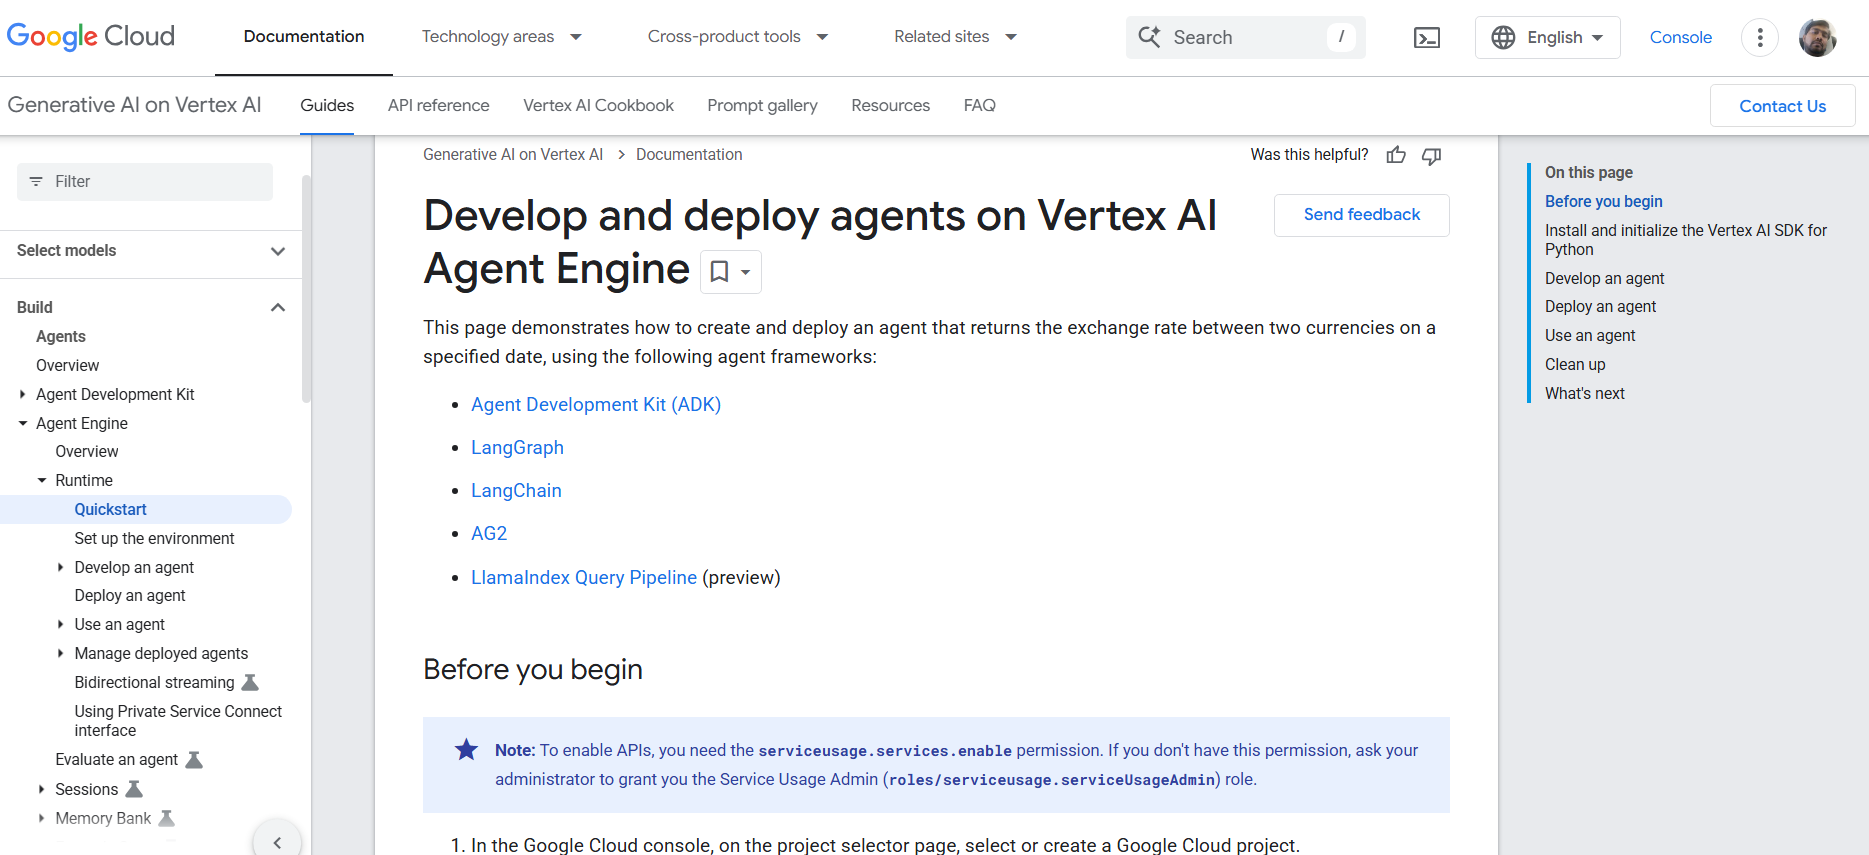

#### Define your agent
These instructions assume you have an existing ADK project that you are modifying for deployment. If you do not have an ADK project, or want to use a test project, complete the Python [Quickstart](https://google.github.io/adk-docs/get-started/quickstart/) guide, which creates a [multi_tool_agent](https://github.com/google/adk-docs/tree/main/examples/python/snippets/get-started/multi_tool_agent) project. The following instructions use the `multi_tool_agent` project as an example.

#### Initialize Vertex AI
Next, initialize the Vertex AI SDK. This tells the SDK which Google Cloud project and region to use, and where to stage files for deployment.

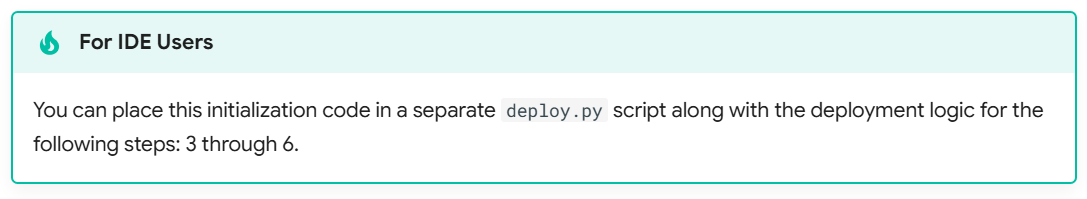

##### **deploy.py**
```Python
import vertexai
from agent import root_agent # modify this if your agent is not in agent.py

# TODO: Fill in these values for your project
PROJECT_ID = "your-gcp-project-id"
LOCATION = "us-central1"  # For other options, see https://cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/overview#supported-regions
STAGING_BUCKET = "gs://your-gcs-bucket-name"

# Initialize the Vertex AI SDK
vertexai.init(
    project=PROJECT_ID,
    location=LOCATION,
    staging_bucket=STAGING_BUCKET,
)
```

#### Prepare the agent for deployment
To make your agent compatible with Agent Engine, you need to wrap it in an `AdkApp` object.

##### **deploy.py**
```Python
from vertexai import agent_engines

# Wrap the agent in an AdkApp object
app = agent_engines.AdkApp(
    agent=root_agent,
    enable_tracing=True,
)
```
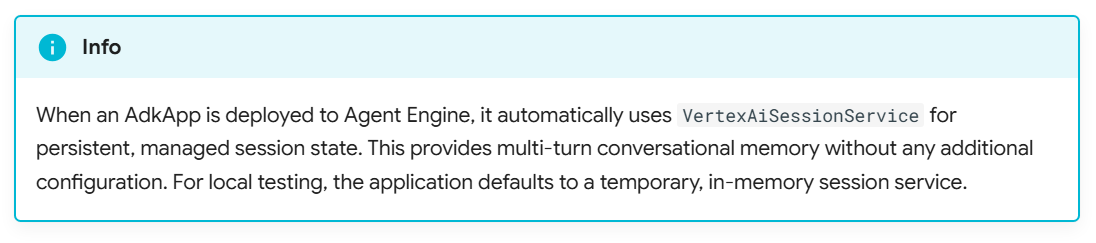

#### Test agent locally (optional)
Before deploying, you can test your agent's behavior locally.

The `async_stream_query` method returns a stream of events that represent the agent's execution trace.

##### **deploy.py**
```Python
# Create a local session to maintain conversation history
session = await app.async_create_session(user_id="u_123")
print(session)
```

Expected output for `create_session` (local):

```bash
Session(id='c6a33dae-26ef-410c-9135-b434a528291f', app_name='default-app-name', user_id='u_123', state={}, events=[], last_update_time=1743440392.8689594)
```

Send a query to the agent. Copy-paste the following code to your "deploy.py" python script or a notebook.

##### **deploy**
```Python
events = []
async for event in app.async_stream_query(
    user_id="u_123",
    session_id=session.id,
    message="whats the weather in new york",
):
    events.append(event)

# The full event stream shows the agent's thought process
print("--- Full Event Stream ---")
for event in events:
    print(event)

# For quick tests, you can extract just the final text response
final_text_responses = [
    e for e in events
    if e.get("content", {}).get("parts", [{}])[0].get("text")
    and not e.get("content", {}).get("parts", [{}])[0].get("function_call")
]
if final_text_responses:
    print("\n--- Final Response ---")
    print(final_text_responses[0]["content"]["parts"][0]["text"])
```

#### Understanding the output
When you run the code above, you will see a few types of events:

- **Tool Call Event**: The model asks to call a tool (e.g., get_weather).

- **Tool Response Event**: The system provides the result of the tool call back to the model.

- **Model Response Event**: The final text response from the agent after it has processed the tool results.

Expected output for `async_stream_query` (local):
```bash
{'parts': [{'function_call': {'id': 'af-a33fedb0-29e6-4d0c-9eb3-00c402969395', 'args': {'city': 'new york'}, 'name': 'get_weather'}}], 'role': 'model'}
{'parts': [{'function_response': {'id': 'af-a33fedb0-29e6-4d0c-9eb3-00c402969395', 'name': 'get_weather', 'response': {'status': 'success', 'report': 'The weather in New York is sunny with a temperature of 25 degrees Celsius (41 degrees Fahrenheit).'}}}], 'role': 'user'}
{'parts': [{'text': 'The weather in New York is sunny with a temperature of 25 degrees Celsius (41 degrees Fahrenheit).'}], 'role': 'model'}
```

#### Deploy to agent engine
Once you are satisfied with your agent's local behavior, you can deploy it. You can do this using the Python SDK or the `adk` command-line tool.

This process packages your code, builds it into a container, and deploys it to the managed Agent Engine service. This process can take several minutes.

This code block initiates the deployment from a Python script or notebook.
##### **deploy.py**
```Python
from vertexai import agent_engines

remote_app = agent_engines.create(
    agent_engine=app,
    requirements=[
        "google-cloud-aiplatform[adk,agent_engines]"   
    ]
)

print(f"Deployment finished!")
print(f"Resource Name: {remote_app.resource_name}")
# Resource Name: "projects/{PROJECT_NUMBER}/locations/{LOCATION}/reasoningEngines/{RESOURCE_ID}"
#       Note: The PROJECT_NUMBER is different than the PROJECT_ID.
```

##### **Monitoring and verification***
- You can monitor the deployment status in the [Agent Engine UI](https://console.cloud.google.com/vertex-ai/agents/agent-engines) in the Google Cloud Console.

- The `remote_app.resource_name` is the unique identifier for your deployed agent. You will need it to interact with the agent. You can also get this from the response returned by the ADK CLI command.

- For additional details, you can visit the Agent Engine documentation [deploying an agent](https://cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/deploy) and [managing deployed agents](https://cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/manage/overview).

##### `Agent Engine UI`
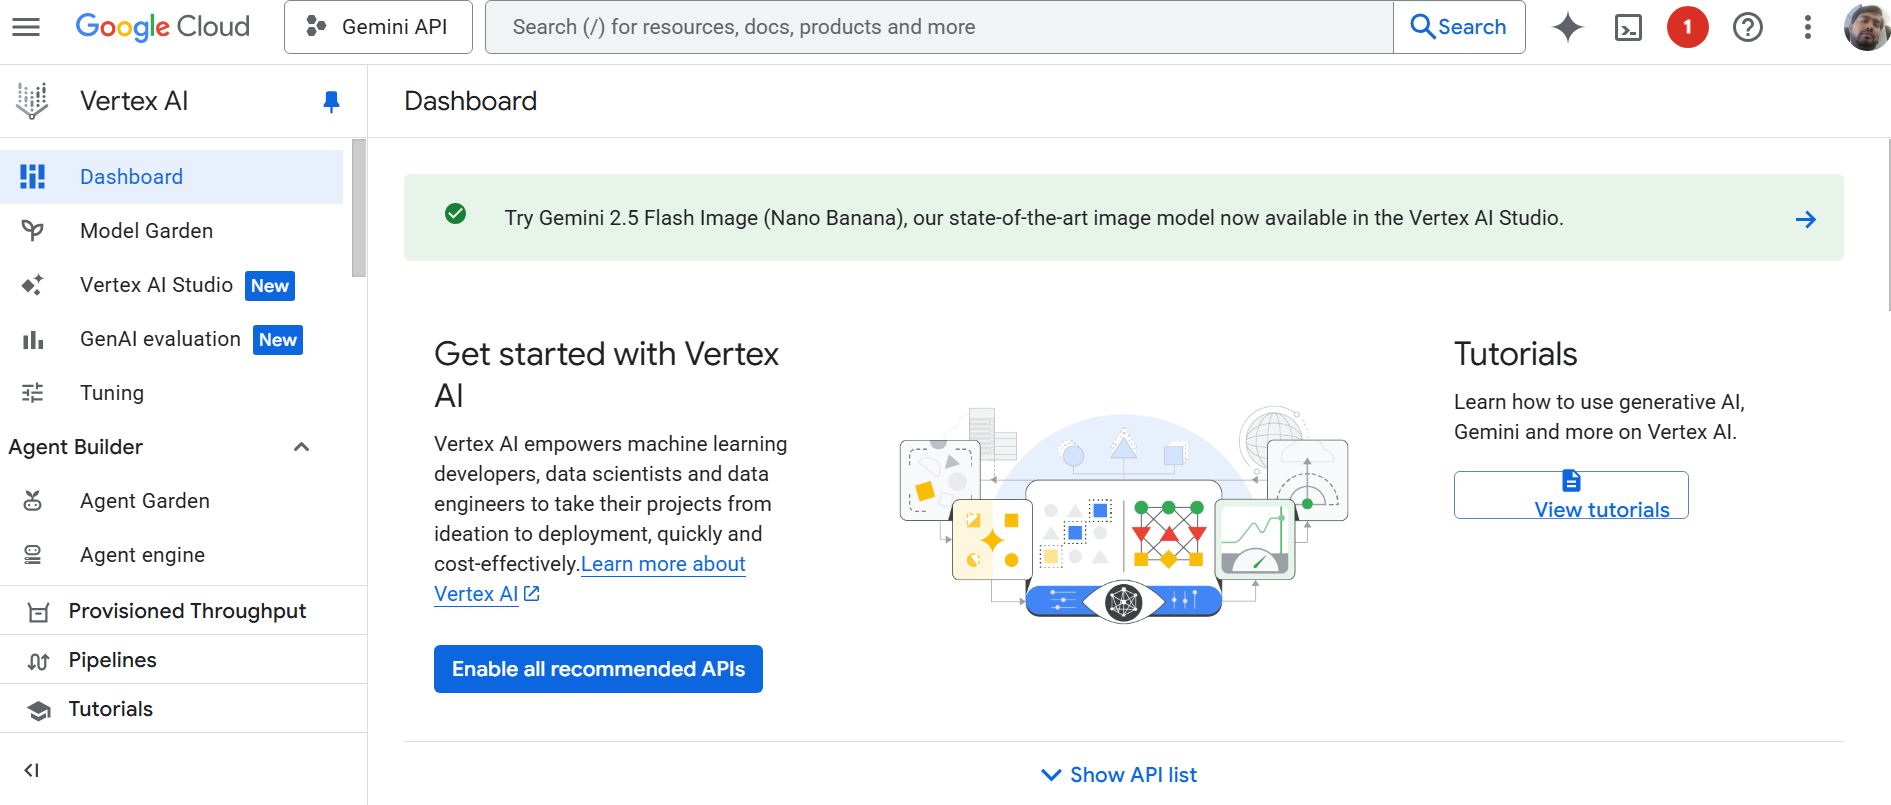 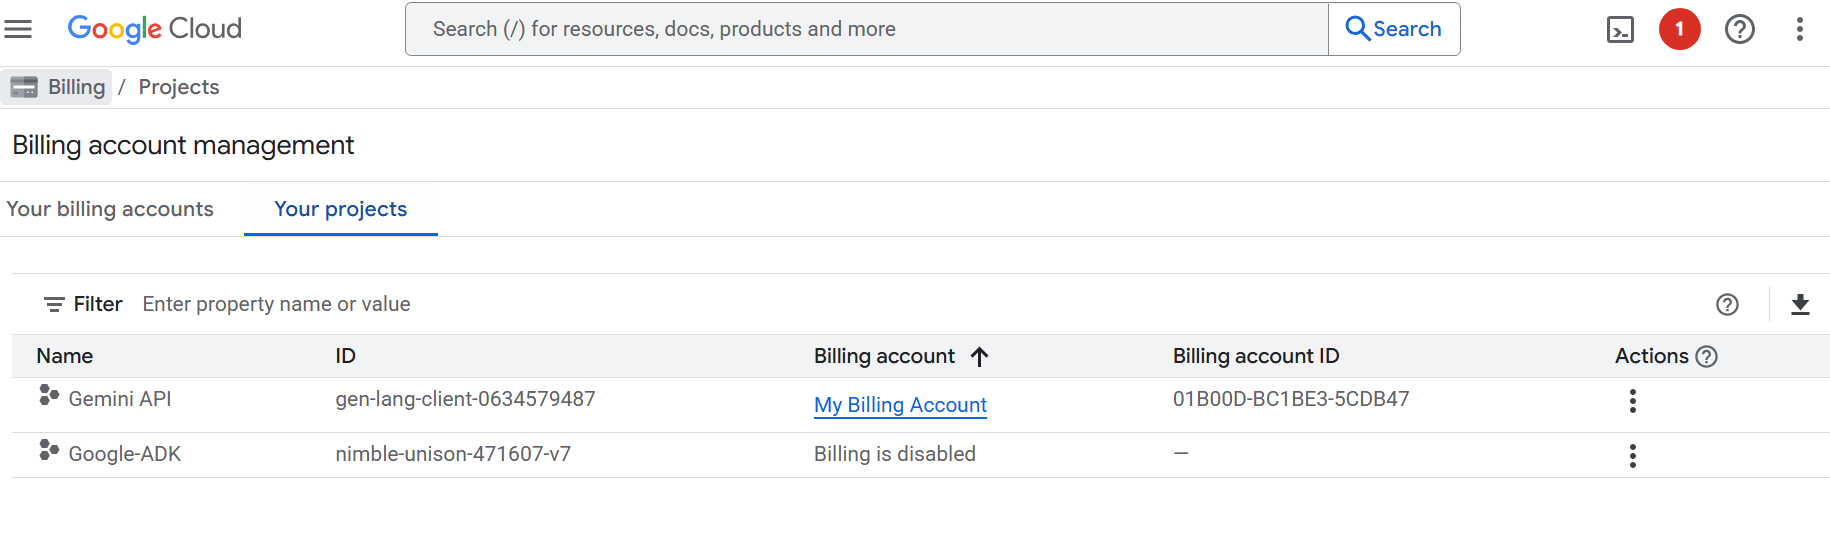

##### `Deploying an Agent`
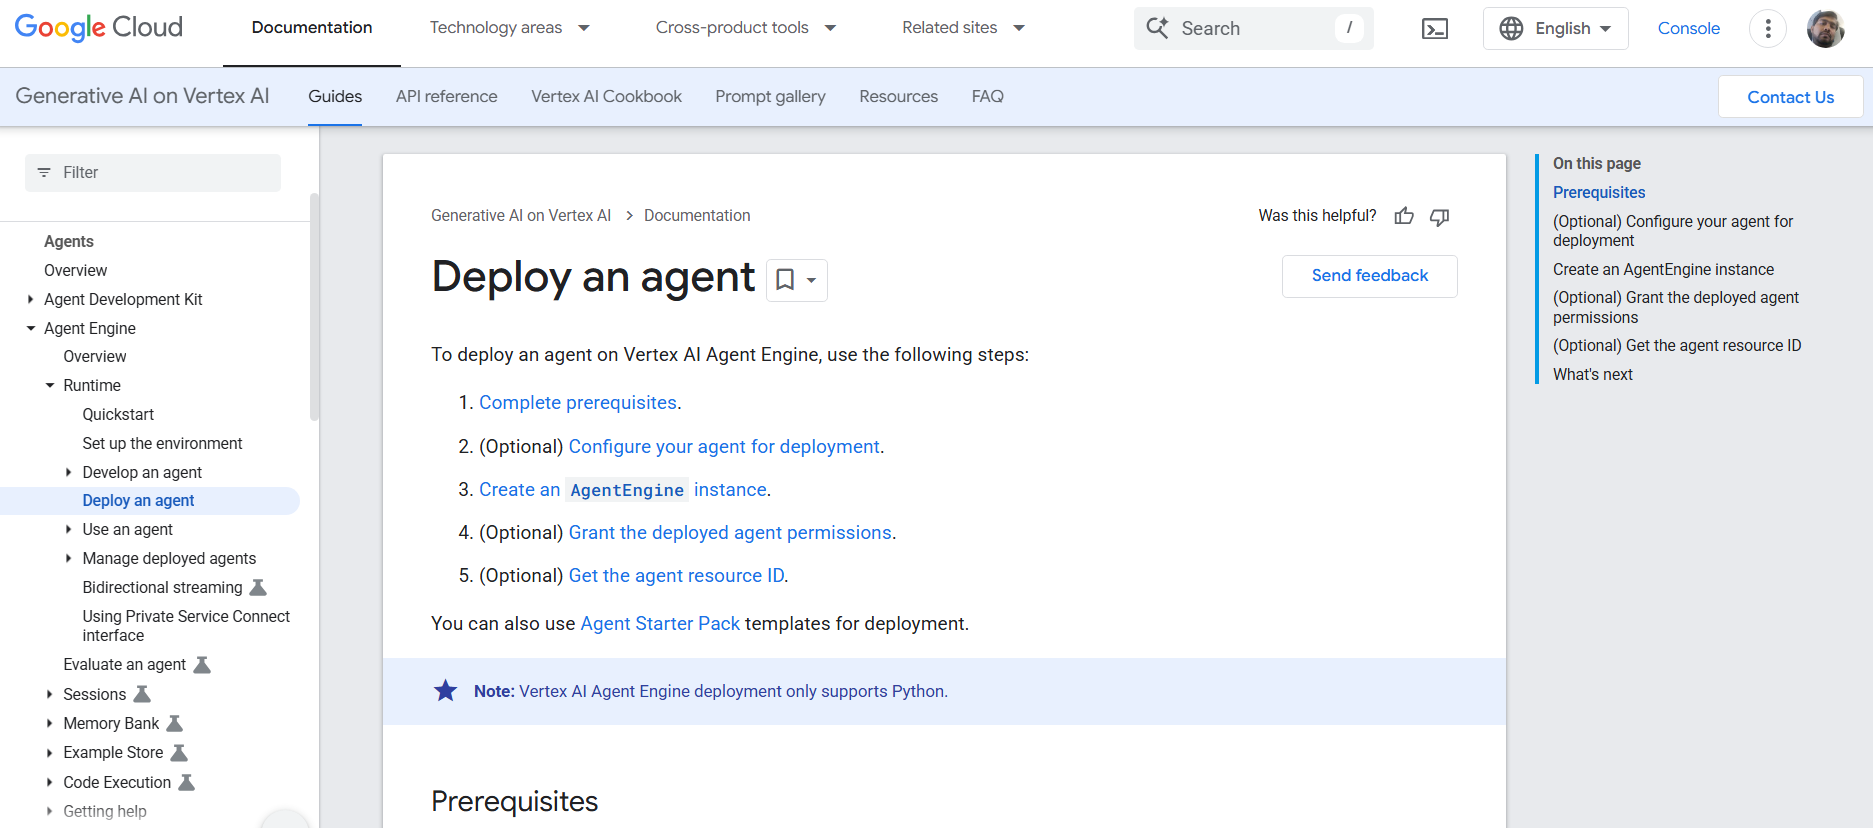

##### `Managing Deployed Agents`
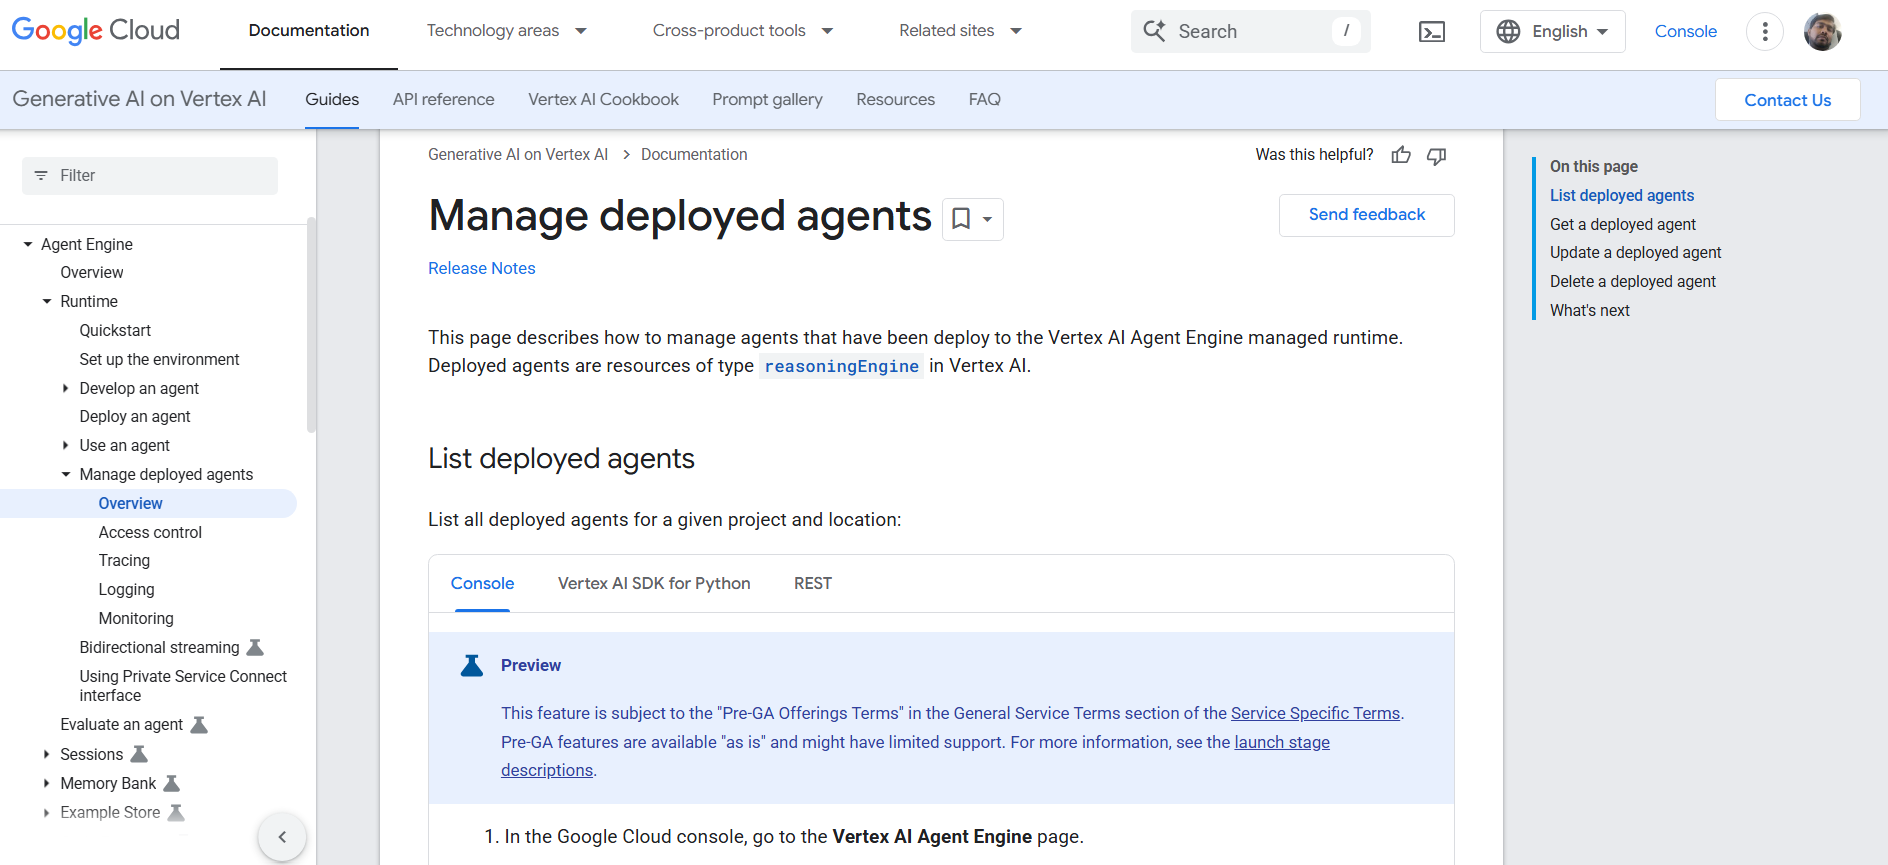

---

### Test deployed agent
Once you have completed the deployment of your agent to Agent Engine, you can view your deployed agent through the Google Cloud Console, and interact with the agent using REST calls or the Vertex AI SDK for Python.

To view your deployed agent in the Cloud Console:
- Navigate to the Agent Engine page in the Google Cloud Console: <br>
    https://console.cloud.google.com/vertex-ai/agents/agent-engines

This page lists all deployed agents in your currently selected Google Cloud project. If you do not see your agent listed, make sure you have your target project selected in Google Cloud Console. For more information on selecting an exising Google Cloud project, see [Creating and managing projects](https://cloud.google.com/resource-manager/docs/creating-managing-projects#identifying_projects)

#### `Creating and managing projects`
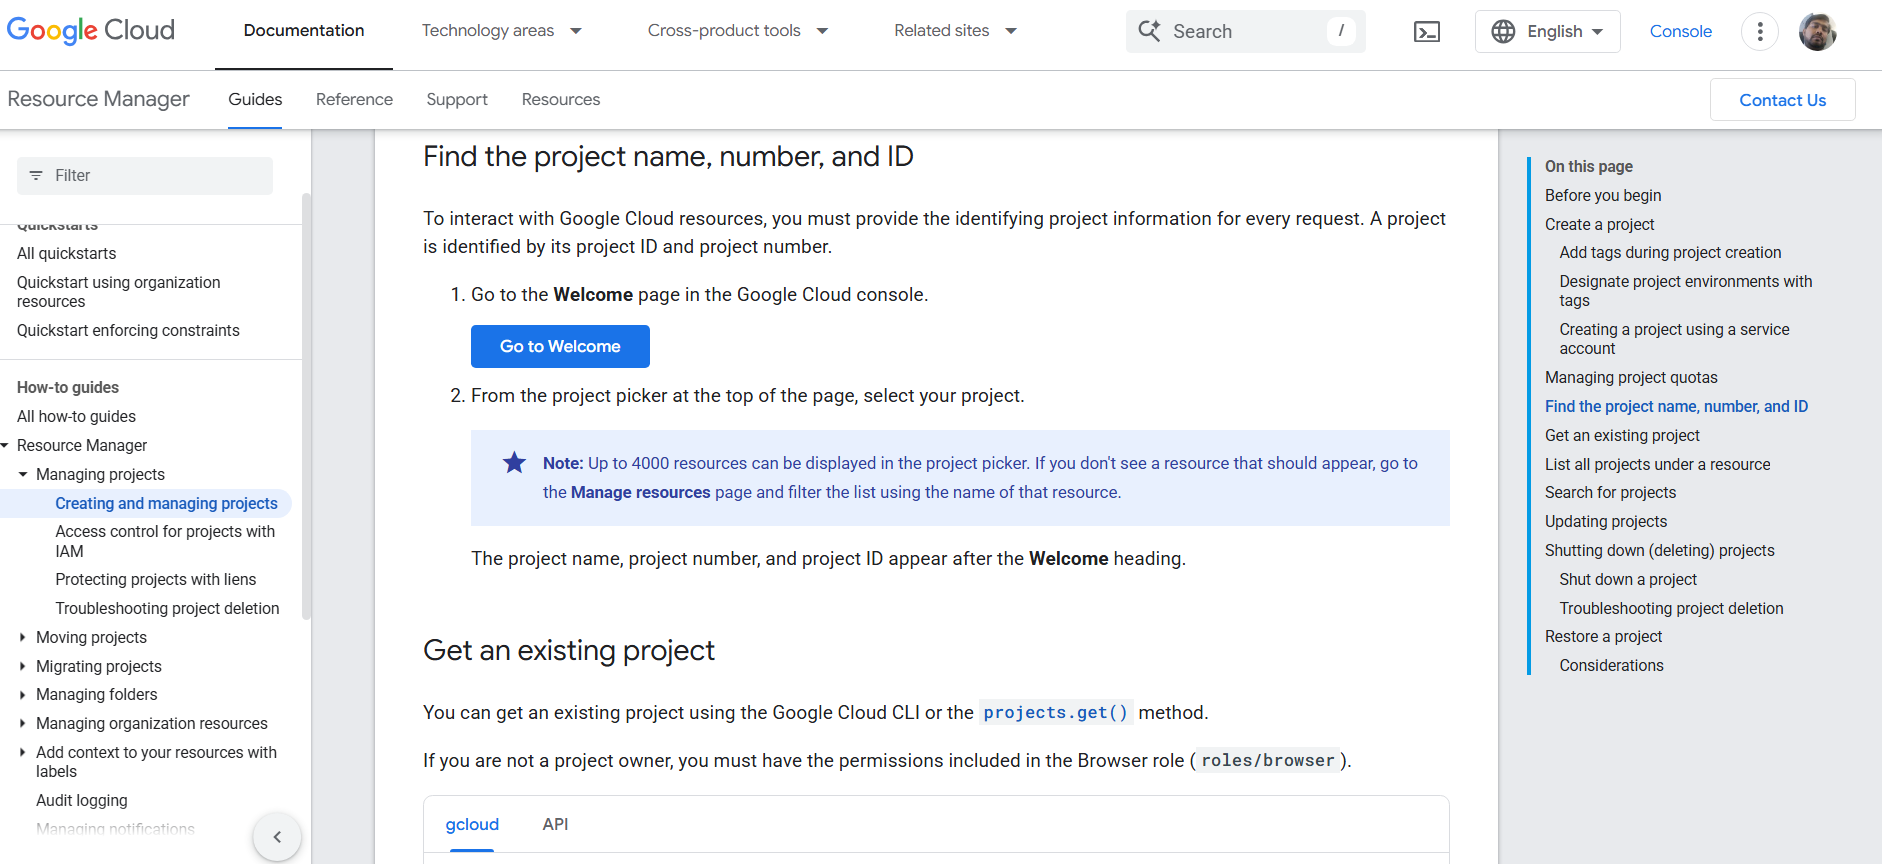

#### Find Google Cloud project information
You need the address and resource identification for your project (`PROJECT_ID`, `LOCATION`, `RESOURCE_ID`) to be able to test your deployment. You can use Cloud Console or the `gcloud` command line tool to find this information.

To find your project information with Google Cloud Console:

1. In the Google Cloud Console, navigate to the Agent Engine page:<br>
    https://console.cloud.google.com/vertex-ai/agents/agent-engines

1. At the top of the page, select **API URLs**, and then copy the **Query URL** string for your deployed agent, which should be in this format:

    ```bash
    https://$(LOCATION_ID)-aiplatform.googleapis.com/v1/projects/$(PROJECT_ID)/locations/$(LOCATION_ID)/reasoningEngines/$(RESOURCE_ID):query
    ```

To find your project information with `gloud`:

1. In your development environment, make sure you are authenticated to Google Cloud and run the following command to list your project:
    ```bash
    gcloud projects list
    ```
1. Take the Project ID used for deployment and run this command to get the additional details:
    ```bash
    gcloud asset search-all-resources \
    --scope=projects/$(PROJECT_ID) \
    --asset-types='aiplatform.googleapis.com/ReasoningEngine' \
    --format="table(name,assetType,location,reasoning_engine_id)"
    ```

#### Test using REST `calls`
A simple way to interact with your deployed agent in Agent Engine is to use REST calls with the `curl` tool. This section describes the how to check your connection to the agent and also to test processing of a request by the deployed agent.

##### **Check connection to agent**
You can check your connection to the running agent using the **Query URL** available in the Agent Engine section of the Cloud Console. This check does not execute the deployed agent, but returns information about the agent.

To send a REST call get a response from deployed agent:

- In a terminal window of your development environment, build a request and execute it:
    ```bash
    curl -X GET \
    -H "Authorization: Bearer $(gcloud auth print-access-token)" \
    "https://$(LOCATION)-aiplatform.googleapis.com/v1/projects/$(PROJECT_ID)/locations/$(LOCATION)/reasoningEngines"
    ```

If your deployment was successful, this request responds with a list of valid requests and expected data formats.

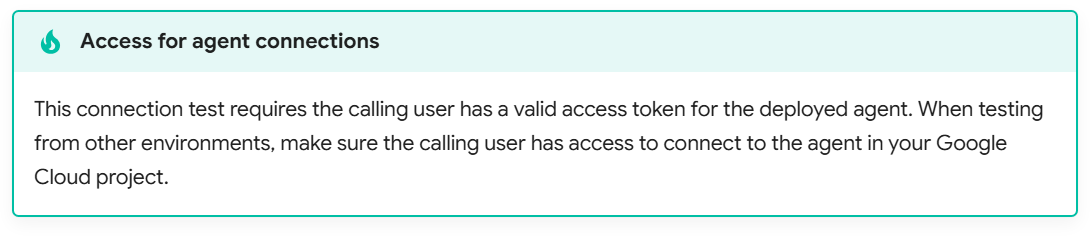

##### **Send an agent request**
When getting responses from your agent project, you must first create a session, receive a Session ID, and then send your requests using that Session ID. This process is described in the following instructions.

To test interaction with the deployed agent via REST:

1. In a terminal window of your development environment, create a session by building a request using this template:

    ```bash
    curl \
    -H "Authorization: Bearer $(gcloud auth print-access-token)" \
    -H "Content-Type: application/json" \
    https://$(LOCATION)-aiplatform.googleapis.com/v1/projects/$(PROJECT_ID)/locations/$(LOCATION)/reasoningEngines/$(RESOURCE_ID):query \
    -d '{"class_method": "async_create_session", "input": {"user_id": "u_123"},}'
    ```

1. In the response to the previous command, extract the created **Session ID** from the **id** field:
    ```bash
    {
        "output": {
            "userId": "u_123",
            "lastUpdateTime": 1757690426.337745,
            "state": {},
            "id": "4857885913439920384", # Session ID
            "appName": "9888888855577777776",
            "events": []
        }
    }
    ```
1. In a terminal window of your development environment, send a message to your agent by building a request using this template and the Session ID created in the previous step:
```bash
curl \
-H "Authorization: Bearer $(gcloud auth print-access-token)" \
-H "Content-Type: application/json" \
https://$(LOCATION)-aiplatform.googleapis.com/v1/projects/$(PROJECT_ID)/locations/$(LOCATION)/reasoningEngines/$(RESOURCE_ID):streamQuery?alt=sse -d '{
"class_method": "async_stream_query",
"input": {
    "user_id": "u_123",
    "session_id": "4857885913439920384",
    "message": "Hey whats the weather in new york today?",
}
}'
```

> This request should generate a response from your deployed agent code in JSON format. For more information about interacting with a deployed ADK agent in Agent Engine using REST calls, see Manage deployed agents and Use a Agent Development Kit agent in the Agent Engine documentation.

---